# **Modelación clustering**

## Librerías

In [12]:
import warnings
warnings.filterwarnings("ignore")

In [13]:
import os
import time
import pickle
import hdbscan
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import tensorflow as tf
from minisom import MiniSom
import plotly.express as px
from tensorflow import keras
from itertools import product
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.utils import resample
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn_extra.cluster import KMedoids
from sklearn.mixture import GaussianMixture
from tensorflow.keras.optimizers import Adam
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model, load_model
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.cluster import KMeans, DBSCAN, Birch, MeanShift, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

## Selección de Variables

In [14]:
with open('taxi_df.pkl', 'rb') as f:
    taxi_df = pickle.load(f)

In [16]:
# seleccion de variables
print(taxi_df.columns)

Index(['PULocationID', 'DOLocationID', 'Passengers', 'Distance', 'RatecodeID',
       'fare_amount', 'total_amount', 'PickUpYear', 'PickUpMonth',
       'PickUpWeek', 'PickUpDay', 'PickUpHour', 'PickUpDayWeek',
       'payment_type', 'tolls_amount', 'Duration', 'Zone_pickup',
       'Zone_dropoff', 'Duration_seconds', 'Duration_minutes',
       'Duration_range', 'Amount_range'],
      dtype='object')


In [17]:
# DataFrame con las variables seleccionadas para los modelos de clustering
variables_clustering = [
    'total_amount',
    'Distance',
    'Passengers',
    'tolls_amount',
    'Duration_seconds',
    'payment_type',
    'RatecodeID'
]

# Crear una copia con solo esas columnas
df_clustering = taxi_df[variables_clustering].copy()

# Mostrar las primeras filas
df_clustering.head()

,total_amount,Distance,Passengers,tolls_amount,Duration_seconds,payment_type,RatecodeID
0,9.95,1.5,1.0,0.0,400.0,1,1.0
1,16.30,2.6,1.0,0.0,1152.0,1,1.0
7,9.05,1.3,1.0,0.0,429.0,1,1.0
8,18.50,3.7,1.0,0.0,818.0,1,1.0
9,13.00,2.1,2.0,0.0,720.0,1,1.0


In [18]:
# Variables
numeric_features = ['Distance', 'Passengers', 'tolls_amount', 'Duration_seconds', 'total_amount']
categorical_features = ['payment_type', 'RatecodeID']
# Preprocesador

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [19]:
X = df_clustering[numeric_features + categorical_features]
X_transf = preprocessor.fit_transform(X)

In [20]:
X_sample = resample(X_transf, n_samples=150000, random_state=42)

# Modelos de Machine Learning

## Kmeans

### Silhouette

In [ ]:
# Definir el rango de parámetros para el ajuste
param_grid = {
    'n_clusters': [2, 3, 4, 5, 6],
    'init': ['k-means++', 'random'],
    'max_iter': [300, 400, 500]
}

# Definir el modelo base
kmeans = KMeans(random_state=42, n_init='auto')

# Función de scoring personalizada para Silhouette
def silhouette_scorer(estimator, X):
    labels = estimator.fit_predict(X)
    return silhouette_score(X, labels)

# Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=kmeans,
    param_grid=param_grid,
    scoring=silhouette_scorer,
    cv=3,
    verbose=1,  
    n_jobs=-1   
)

print(" Comenzando la búsqueda de hiperparámetros...\n")
grid_search.fit(X_sample)

# Mostrar mejores parámetros
print("\n Mejores parámetros encontrados:")
print(grid_search.best_params_)

# -------------------------------------------
#  Mostrar tabla completa de resultados
# -------------------------------------------
print("\n Resultados completos ordenados por mejor score:\n")

# Crear DataFrame con resultados
results_df = pd.DataFrame(grid_search.cv_results_)

# Seleccionar columnas útiles
columns_to_show = ['params', 'mean_test_score', 'std_test_score', 'mean_fit_time', 'mean_score_time']
results_df = results_df[columns_to_show]

# Ordenar por mayor Silhouette Score
results_df_sorted = results_df.sort_values(by='mean_test_score', ascending=False)

# Mostrar todo
pd.set_option('display.max_rows', None)  # Mostrar todas las filas
print(results_df_sorted)


 Comenzando la búsqueda de hiperparámetros...

Fitting 3 folds for each of 30 candidates, totalling 90 fits

 Mejores parámetros encontrados:
{'init': 'k-means++', 'max_iter': 300, 'n_clusters': 2}

 Resultados completos ordenados por mejor score:

                                               params  mean_test_score  \
0   {'init': 'k-means++', 'max_iter': 300, 'n_clus...         0.769978   
5   {'init': 'k-means++', 'max_iter': 400, 'n_clus...         0.769978   
10  {'init': 'k-means++', 'max_iter': 500, 'n_clus...         0.769978   
25  {'init': 'random', 'max_iter': 500, 'n_cluster...         0.712788   
20  {'init': 'random', 'max_iter': 400, 'n_cluster...         0.712788   
15  {'init': 'random', 'max_iter': 300, 'n_cluster...         0.712788   
6   {'init': 'k-means++', 'max_iter': 400, 'n_clus...         0.658873   
11  {'init': 'k-means++', 'max_iter': 500, 'n_clus...         0.658873   
1   {'init': 'k-means++', 'max_iter': 300, 'n_clus...         0.658873   
3   {'init'

In [ ]:
# Extraer mejores parámetros desde grid_search
best_params = grid_search.best_params_

# Crear el modelo con los mejores parámetros
kmeans_silhouette = KMeans(
    n_clusters=best_params['n_clusters'],
    init=best_params['init'],
    max_iter=best_params['max_iter'],
    random_state=42,
    n_init='auto'
)

# Entrenar el modelo
kmeans_silhouette.fit(X_sample)

# Obtener las etiquetas del modelo
labels_silhouette = kmeans_silhouette.labels_

# Calcular métricas
silhouette_final = silhouette_score(X_sample, labels_silhouette)
davies_bouldin_final = davies_bouldin_score(X_sample, labels_silhouette)
calinski_harabasz_final = calinski_harabasz_score(X_sample, labels_silhouette)

# Imprimir resultados
print(f"Silhouette Score (final): {silhouette_final:.4f}")
print(f"Davies-Bouldin Score (final): {davies_bouldin_final:.4f}")
print(f"Calinski-Harabasz Score (final): {calinski_harabasz_final:.4f}")

Silhouette Score (final): 0.7129
Davies-Bouldin Score (final): 0.7252
Calinski-Harabasz Score (final): 86988.6291


### Davies-Bouldin

In [ ]:
# Definir el rango de parámetros para el ajuste
param_grid = {
    'n_clusters': [2, 3, 4, 5, 6],
    'init': ['k-means++', 'random'],
    'max_iter': [300, 400, 500]
}

# Definir el modelo KMeans
kmeans = KMeans(random_state=42, n_init='auto')

# Definir una función de scoring para Davies-Bouldin (negativo)
def negative_davies_bouldin(estimator, X):
    labels = estimator.fit_predict(X)
    score = davies_bouldin_score(X, labels)
    return -score

# Realizar la búsqueda de hiperparámetros
grid_search = GridSearchCV(kmeans, param_grid, cv=3, scoring=negative_davies_bouldin)

print("Comenzando la búsqueda de hiperparámetros...")

results = []

grid_search.fit(X_sample) # Ajustar GridSearchCV

for i in range(len(grid_search.cv_results_['params'])):
    params = grid_search.cv_results_['params'][i]
    mean_neg_db = grid_search.cv_results_['mean_test_score'][i]
    duration = grid_search.cv_results_['mean_fit_time'][i] + grid_search.cv_results_['mean_score_time'][i]
    results.append((params, mean_neg_db, duration))
    print(f"Parámetros: {params}, Score Promedio (neg_Davies-Bouldin): {mean_neg_db:.4f}, Tiempo: {duration:.2f} segundos")

# Mostrar todos los resultados
print("\nTodos los resultados de la búsqueda:")
for params, score, duration in results:
    print(f"Parámetros: {params}, Score Promedio (neg_Davies-Bouldin): {score:.4f}, Tiempo: {duration:.2f} segundos")

# Mostrar el mejor conjunto de hiperparámetros
print("\nMejores parámetros: ", grid_search.best_params_)


Comenzando la búsqueda de hiperparámetros...
Parámetros: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 2}, Score Promedio (neg_Davies-Bouldin): -0.5514, Tiempo: 0.04 segundos
Parámetros: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 3}, Score Promedio (neg_Davies-Bouldin): -0.6333, Tiempo: 0.05 segundos
Parámetros: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 4}, Score Promedio (neg_Davies-Bouldin): -0.6586, Tiempo: 0.05 segundos
Parámetros: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 5}, Score Promedio (neg_Davies-Bouldin): -0.6913, Tiempo: 0.06 segundos
Parámetros: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 6}, Score Promedio (neg_Davies-Bouldin): -0.7532, Tiempo: 0.06 segundos
Parámetros: {'init': 'k-means++', 'max_iter': 400, 'n_clusters': 2}, Score Promedio (neg_Davies-Bouldin): -0.5514, Tiempo: 0.04 segundos
Parámetros: {'init': 'k-means++', 'max_iter': 400, 'n_clusters': 3}, Score Promedio (neg_Davies-Bouldin): -0.6333, Tiempo: 0.05 segun

In [ ]:
# Crear el modelo con los mejores parámetros encontrados por MSE
kmeans_davies = KMeans(n_clusters=2, init='k-means++', max_iter=300, random_state=42)

# Entrenar el modelo
kmeans_davies.fit(X_sample)

# Obtener las etiquetas del modelo basado en MSE
labels_davies = kmeans_davies.labels_

# Calcular métricas
silhouette_mse = silhouette_score(X_sample, labels_davies)
davies_bouldin_mse = davies_bouldin_score(X_sample, labels_davies)
calinski_harabasz_mse = calinski_harabasz_score(X_sample, labels_davies)

# Imprimir resultados
print(f"Silhouette Score (MSE): {silhouette_mse:.4f}")
print(f"Davies-Bouldin Score (MSE): {davies_bouldin_mse:.4f}")
print(f"Calinski-Harabasz Score (MSE): {calinski_harabasz_mse:.4f}")

Silhouette Score (MSE): 0.7129
Davies-Bouldin Score (MSE): 0.7252
Calinski-Harabasz Score (MSE): 86988.6291


### Calinski-Harabasz

In [ ]:
# Definir el rango de parámetros para el ajuste
param_grid = {
    'n_clusters': [2, 3, 4, 5, 6],
    'init': ['k-means++', 'random'],
    'max_iter': [300, 400, 500]
}

# Definir el modelo KMeans
kmeans = KMeans(random_state=42, n_init='auto')

# Definir función de scoring con Calinski-Harabasz
def calinski_harabasz_scorer(estimator, X):
    labels = estimator.fit_predict(X)
    score = calinski_harabasz_score(X, labels)
    return score  # Se maximiza

# Realizar la búsqueda de hiperparámetros con uso de todos los núcleos
grid_search = GridSearchCV(
    estimator=kmeans,
    param_grid=param_grid,
    cv=3,
    scoring=calinski_harabasz_scorer,
    n_jobs=-1,  
    verbose=2   
)

print("Comenzando la búsqueda de hiperparámetros...")

results = []

grid_search.fit(X_sample)  # Ajustar GridSearchCV

for i in range(len(grid_search.cv_results_['params'])):
    params = grid_search.cv_results_['params'][i]
    mean_ch = grid_search.cv_results_['mean_test_score'][i]
    duration = grid_search.cv_results_['mean_fit_time'][i] + grid_search.cv_results_['mean_score_time'][i]
    results.append((params, mean_ch, duration))
    print(f"Parámetros: {params}, Score Promedio (Calinski-Harabasz): {mean_ch:.4f}, Tiempo: {duration:.2f} segundos")

# Mostrar todos los resultados
print("\nTodos los resultados de la búsqueda:")
for params, score, duration in results:
    print(f"Parámetros: {params}, Score Promedio (Calinski-Harabasz): {score:.4f}, Tiempo: {duration:.2f} segundos")

# Mostrar el mejor conjunto de hiperparámetros
print("\nMejores parámetros: ", grid_search.best_params_)

Comenzando la búsqueda de hiperparámetros...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Parámetros: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 2}, Score Promedio (Calinski-Harabasz): 22655.3701, Tiempo: 0.21 segundos
Parámetros: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 3}, Score Promedio (Calinski-Harabasz): 28406.8834, Tiempo: 0.32 segundos
Parámetros: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 4}, Score Promedio (Calinski-Harabasz): 32103.1283, Tiempo: 0.26 segundos
Parámetros: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 5}, Score Promedio (Calinski-Harabasz): 36640.7579, Tiempo: 0.39 segundos
Parámetros: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 6}, Score Promedio (Calinski-Harabasz): 39394.7964, Tiempo: 0.48 segundos
Parámetros: {'init': 'k-means++', 'max_iter': 400, 'n_clusters': 2}, Score Promedio (Calinski-Harabasz): 22655.3701, Tiempo: 0.19 segundos
Parámetros: {'init': 'k-means++', 'max_iter': 400, 'n_cluste

In [ ]:
# Extraer los mejores parámetros del grid search
best_params_ch = grid_search.best_params_

# Crear el modelo con los mejores parámetros
kmeans_ch = KMeans(
    n_clusters=best_params_ch['n_clusters'],
    init=best_params_ch['init'],
    max_iter=best_params_ch['max_iter'],
    random_state=42,
    n_init='auto'
)

# Entrenar el modelo
kmeans_ch.fit(X_sample)

# Obtener las etiquetas del modelo
labels_ch = kmeans_ch.labels_

# Calcular las métricas
silhouette_ch = silhouette_score(X_sample, labels_ch)
davies_bouldin_ch = davies_bouldin_score(X_sample, labels_ch)
calinski_harabasz_ch = calinski_harabasz_score(X_sample, labels_ch)

# Mostrar métricas
print(f"Silhouette Score (CH): {silhouette_ch:.4f}")
print(f"Davies-Bouldin Score (CH): {davies_bouldin_ch:.4f}")
print(f"Calinski-Harabasz Score (CH): {calinski_harabasz_ch:.4f}")


Silhouette Score (CH): 0.5121
Davies-Bouldin Score (CH): 0.6943
Calinski-Harabasz Score (CH): 125011.9021


### Visualización Clusters K-Means

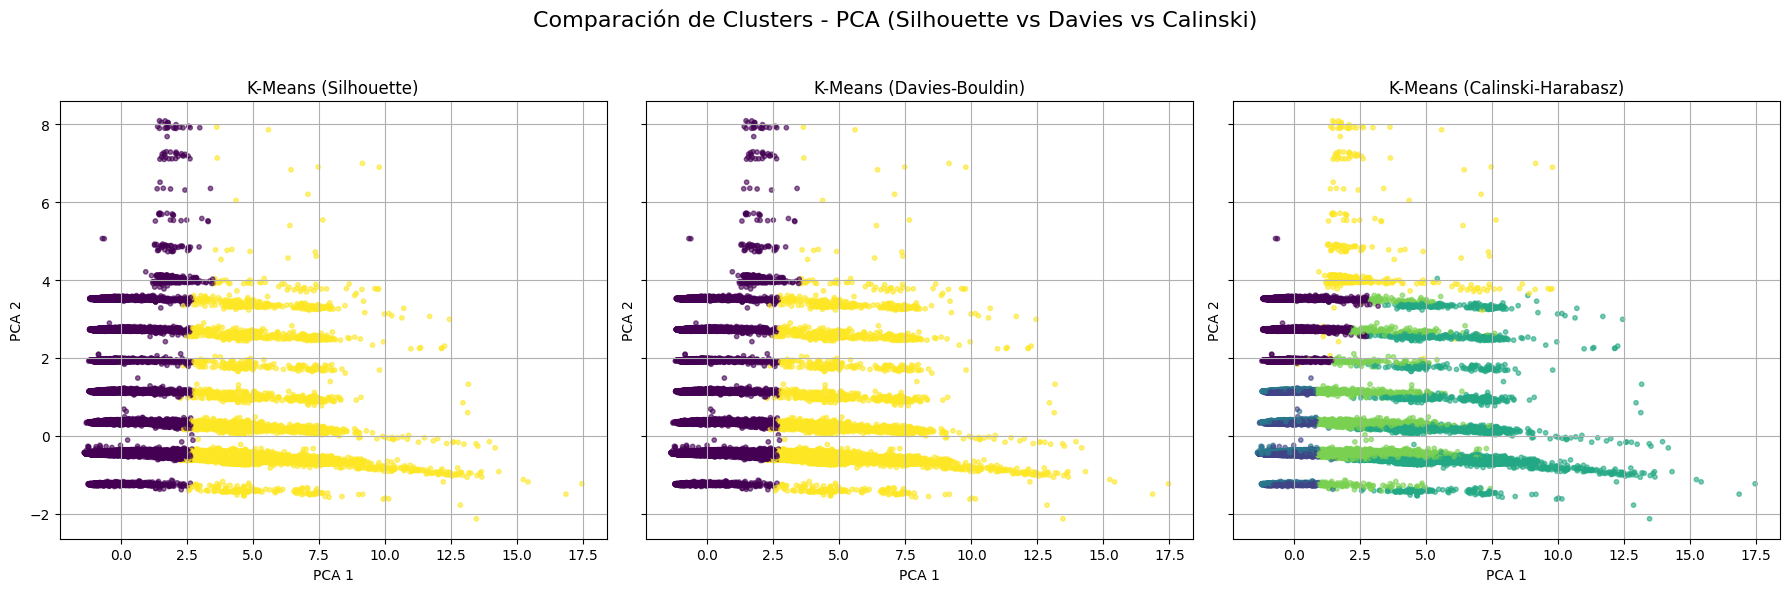

In [ ]:
# Aplicamos PCA solo una vez a X_sample (mismo espacio para todos)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

# Diccionario con los modelos y etiquetas
modelos = {
    'Silhouette': kmeans_silhouette.labels_,
    'Davies-Bouldin': kmeans_davies.labels_,
    'Calinski-Harabasz': kmeans_ch.labels_
}

# Crear figura con 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

# Recorrer los modelos y graficarlos en subplots
for i, (titulo, labels) in enumerate(modelos.items()):
    axs[i].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=10, alpha=0.6)
    axs[i].set_title(f'K-Means ({titulo})')
    axs[i].set_xlabel('PCA 1')
    axs[i].set_ylabel('PCA 2')
    axs[i].grid(True)

plt.suptitle('Comparación de Clusters - PCA (Silhouette vs Davies vs Calinski)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## DBSCAN

### Silhouette

In [ ]:
# Definir el rango de parámetros para DBSCAN
param_grid_dbscan = [
    {'eps': eps, 'min_samples': min_samples}
    for eps in np.arange(0.1, 1.0, 0.1)
    for min_samples in range(5, 50, 5)
]

# Objeto para dividir los datos en 3 folds
kf = KFold(n_splits=3, shuffle=True, random_state=42)

results_dbscan = []

print(" Comenzando la búsqueda de hiperparámetros para DBSCAN...\n")
for params in tqdm(param_grid_dbscan, desc="Buscando"):
    scores = []
    fit_times = []
    score_times = []

    for train_index, val_index in kf.split(X_sample):
        X_train, X_val = X_sample[train_index], X_sample[val_index]
        
        start_fit = time.time()
        dbscan_temp = DBSCAN(**params)
        labels_train = dbscan_temp.fit_predict(X_train)
        fit_times.append(time.time() - start_fit)

        start_score = time.time()
        score = -1
        if len(np.unique(labels_train)) > 1:
            labels_val = dbscan_temp.fit_predict(X_val)
            if len(np.unique(labels_val)) > 1:
                score = silhouette_score(X_val, labels_val)
        scores.append(score)
        score_times.append(time.time() - start_score)

    mean_silhouette = np.mean(scores)
    mean_fit_time = np.mean(fit_times)
    mean_score_time = np.mean(score_times)
    duration = mean_fit_time + mean_score_time

    results_dbscan.append((params, mean_silhouette, duration))
    tqdm.write(f"Parámetros: {params}, Silhouette Score Promedio: {mean_silhouette:.4f}, Tiempo total: {duration:.2f} segundos")

# Mostrar todos los resultados
print("\n Resultados de la búsqueda:")
for params, score, duration in results_dbscan:
    print(f"Parámetros: {params}, Silhouette Score Promedio: {score:.4f}, Tiempo: {duration:.2f} s")

# Obtener los mejores parámetros
best_result = max(results_dbscan, key=lambda x: x[1])
best_params_dbscan = best_result[0]
best_score_dbscan = best_result[1]

print("\n Mejores parámetros encontrados para DBSCAN:")
print(f"Parámetros: {best_params_dbscan}")
print(f" Mejor Silhouette Score: {best_score_dbscan:.4f}")


🔍 Comenzando la búsqueda de hiperparámetros para DBSCAN...



Buscando:   1%|          | 1/81 [02:17<3:03:33, 137.66s/it]

Parámetros: {'eps': 0.1, 'min_samples': 5}, Silhouette Score Promedio: 0.2037, Tiempo total: 45.88 segundos


Buscando:   2%|▏         | 2/81 [04:40<3:05:06, 140.59s/it]

Parámetros: {'eps': 0.1, 'min_samples': 10}, Silhouette Score Promedio: 0.2618, Tiempo total: 47.54 segundos


...

Parámetros: {'eps': 0.9, 'min_samples': 35}, Silhouette Score Promedio: 0.2815, Tiempo total: 137.59 segundos


Buscando:  99%|█████████▉| 80/81 [5:27:16<06:42, 402.95s/it]

Parámetros: {'eps': 0.9, 'min_samples': 40}, Silhouette Score Promedio: 0.2781, Tiempo total: 136.91 segundos


Buscando: 100%|██████████| 81/81 [5:34:03<00:00, 247.45s/it]

Parámetros: {'eps': 0.9, 'min_samples': 45}, Silhouette Score Promedio: 0.2819, Tiempo total: 135.65 segundos

📊 Resultados de la búsqueda:
Parámetros: {'eps': 0.1, 'min_samples': 5}, Silhouette Score Promedio: 0.2037, Tiempo: 45.88 s
Parámetros: {'eps': 0.1, 'min_samples': 10}, Silhouette Score Promedio: 0.2618, Tiempo: 47.54 s
Parámetros: {'eps': 0.1, 'min_samples': 15}, Silhouette Score Promedio: 0.2622, Tiempo: 47.68 s
Parámetros: {'eps': 0.1, 'min_samples': 20}, Silhouette Score Promedio: 0.2805, Tiempo: 47.38 s
Parámetros: {'eps': 0.1, 'min_samples': 25}, Silhouette Score Promedio: 0.2889, Tiempo: 46.67 s
Parámetros: {'eps': 0.1, 'min_samples': 30}, Silhouette Score Promedio: 0.2600, Tiempo: 46.00 s
Parámetros: {'eps': 0.1, 'min_samples': 35}, Silhouette Score Promedio: 0.3026, Tiempo: 45.63 s
Parámetros: {'eps': 0.1, 'min_samples': 40}, Silhouette Score Promedio: 0.3185, Tiempo: 45.67 s
Parámetros: {'eps': 0.1, 'min_samples': 45}, Silhouette Score Promedio: 0.3252, Tiempo: 45.11

In [9]:
# Mejores hiperparámetros
best_eps = 0.8
best_min_samples = 5

# Ajustar el modelo final en el subconjunto
dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels_final = dbscan_final.fit_predict(X_sample)

# Calcular métricas si hay más de un cluster
if len(set(labels_final)) > 1:
    silhouette = silhouette_score(X_sample, labels_final)
    davies_bouldin = davies_bouldin_score(X_sample, labels_final)
    calinski_harabasz = calinski_harabasz_score(X_sample, labels_final)
    
    n_clusters = len(set(labels_final)) - (1 if -1 in labels_final else 0)

    print(f" Métricas del modelo final DBSCAN (sobre muestra):")
    print(f"• Número de clusters encontrados: {n_clusters}")
    print(f"• Silhouette Score: {silhouette:.4f}")
    print(f"• Davies-Bouldin Score: {davies_bouldin:.4f}")
    print(f"• Calinski-Harabasz Score: {calinski_harabasz:.4f}")
else:
    print(" No se pueden calcular las métricas porque DBSCAN no formó más de un cluster válido.")


 Métricas del modelo final DBSCAN (sobre muestra):
• Número de clusters encontrados: 110
• Silhouette Score: 0.3539
• Davies-Bouldin Score: 1.6536
• Calinski-Harabasz Score: 5699.6303


### Davies - Bouldin

In [ ]:
# Definir el rango de parámetros para DBSCAN
param_grid_dbscan = [
    {'eps': eps, 'min_samples': min_samples}
    for eps in np.arange(0.1, 1.0, 0.1)
    for min_samples in range(5, 50, 5)
]

# Objeto para dividir los datos en 3 folds
kf = KFold(n_splits=3, shuffle=True, random_state=42)

results_dbscan = []

print(" Comenzando la búsqueda de hiperparámetros para DBSCAN con Davies-Bouldin...\n")
for params in tqdm(param_grid_dbscan, desc="Buscando"):
    scores = []
    fit_times = []
    score_times = []

    for train_index, val_index in kf.split(X_sample):
        X_train, X_val = X_sample[train_index], X_sample[val_index]

        start_fit = time.time()
        dbscan_temp = DBSCAN(**params)
        labels_train = dbscan_temp.fit_predict(X_train)
        fit_times.append(time.time() - start_fit)

        start_score = time.time()
        score = np.inf  # Davies-Bouldin se minimiza
        if len(np.unique(labels_train)) > 1:
            labels_val = dbscan_temp.fit_predict(X_val)
            if len(np.unique(labels_val)) > 1:
                score = davies_bouldin_score(X_val, labels_val)
        scores.append(score)
        score_times.append(time.time() - start_score)

    mean_db = np.mean(scores)
    mean_fit_time = np.mean(fit_times)
    mean_score_time = np.mean(score_times)
    duration = mean_fit_time + mean_score_time

    results_dbscan.append((params, mean_db, duration))
    tqdm.write(f"Parámetros: {params}, DB Score Promedio: {mean_db:.4f}, Tiempo total: {duration:.2f} segundos")

# Mostrar todos los resultados
print("\n Resultados de la búsqueda:")
for params, score, duration in results_dbscan:
    print(f"Parámetros: {params}, DB Score Promedio: {score:.4f}, Tiempo: {duration:.2f} s")

# Obtener los mejores parámetros (mínimo DB)
best_result = min(results_dbscan, key=lambda x: x[1])
best_params_dbscan = best_result[0]
best_score_dbscan = best_result[1]

print("\n Mejores parámetros encontrados para DBSCAN:")
print(f"Parámetros: {best_params_dbscan}")
print(f"Mejor Davies-Bouldin Score: {best_score_dbscan:.4f}")

🌀 Comenzando la búsqueda de hiperparámetros para DBSCAN con Davies-Bouldin...



Buscando:   1%|          | 1/81 [01:19<1:45:36, 79.20s/it]

Parámetros: {'eps': 0.1, 'min_samples': 5}, DB Score Promedio: 1.2574, Tiempo total: 26.39 segundos


Buscando:   2%|▏         | 2/81 [02:37<1:43:45, 78.80s/it]

Parámetros: {'eps': 0.1, 'min_samples': 10}, DB Score Promedio: 1.1944, Tiempo total: 26.16 segundos


...

Parámetros: {'eps': 0.9, 'min_samples': 35}, DB Score Promedio: 1.6030, Tiempo total: 128.25 segundos


Buscando:  99%|█████████▉| 80/81 [5:05:59<06:17, 377.37s/it]

Parámetros: {'eps': 0.9, 'min_samples': 40}, DB Score Promedio: 1.6648, Tiempo total: 128.81 segundos


Buscando: 100%|██████████| 81/81 [5:12:27<00:00, 231.45s/it]

Parámetros: {'eps': 0.9, 'min_samples': 45}, DB Score Promedio: 1.6701, Tiempo total: 129.25 segundos

 Resultados de la búsqueda:
Parámetros: {'eps': 0.1, 'min_samples': 5}, DB Score Promedio: 1.2574, Tiempo: 26.39 s
Parámetros: {'eps': 0.1, 'min_samples': 10}, DB Score Promedio: 1.1944, Tiempo: 26.16 s
Parámetros: {'eps': 0.1, 'min_samples': 15}, DB Score Promedio: 1.1763, Tiempo: 26.05 s
Parámetros: {'eps': 0.1, 'min_samples': 20}, DB Score Promedio: 1.1101, Tiempo: 25.97 s
Parámetros: {'eps': 0.1, 'min_samples': 25}, DB Score Promedio: 1.0603, Tiempo: 27.28 s
Parámetros: {'eps': 0.1, 'min_samples': 30}, DB Score Promedio: 1.1028, Tiempo: 28.86 s
Parámetros: {'eps': 0.1, 'min_samples': 35}, DB Score Promedio: 1.0640, Tiempo: 27.07 s
Parámetros: {'eps': 0.1, 'min_samples': 40}, DB Score Promedio: 1.0517, Tiempo: 27.61 s
Parámetros: {'eps': 0.1, 'min_samples': 45}, DB Score Promedio: 1.0581, Tiempo: 27.24 s
Parámetros: {'eps': 0.2, 'min_samples': 5}, DB Score Promedio: 1.2918, Tiempo:

In [11]:
# Definir directamente los mejores hiperparámetros encontrados
best_eps = 0.2
best_min_samples = 45

# Entrenar el modelo con los mejores parámetros
dbscan_best = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels_dbscan = dbscan_best.fit_predict(X_sample)

# Calcular métricas (solo si hay más de un cluster válido)
if len(set(labels_dbscan)) > 1:
    silhouette_dbscan = silhouette_score(X_sample, labels_dbscan)
    davies_bouldin_dbscan = davies_bouldin_score(X_sample, labels_dbscan)
    calinski_harabasz_dbscan = calinski_harabasz_score(X_sample, labels_dbscan)

    n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
    n_noise_dbscan = list(labels_dbscan).count(-1)

    print(f"\n🔍 Métricas del modelo DBSCAN con eps={best_eps} y min_samples={best_min_samples}:")
    print(f"• Número de clusters encontrados: {n_clusters_dbscan}")
    print(f"• Número de puntos ruido: {n_noise_dbscan}")
    print(f"• Silhouette Score: {silhouette_dbscan:.4f}")
    print(f"• Davies-Bouldin Score: {davies_bouldin_dbscan:.4f}")
    print(f"• Calinski-Harabasz Score: {calinski_harabasz_dbscan:.4f}")
else:
    print(f"\n❗ DBSCAN con eps={best_eps} y min_samples={best_min_samples} no encontró más de un clúster válido.")



🔍 Métricas del modelo DBSCAN con eps=0.2 y min_samples=45:
• Número de clusters encontrados: 27
• Número de puntos ruido: 9303
• Silhouette Score: 0.3184
• Davies-Bouldin Score: 1.1676
• Calinski-Harabasz Score: 7957.5621


### Calinski - Harabasz

In [ ]:
# Definir el rango de parámetros para DBSCAN
param_grid_dbscan = [
    {'eps': eps, 'min_samples': min_samples}
    for eps in np.arange(0.1, 1.0, 0.1)
    for min_samples in range(5, 50, 5)
]

# Objeto para dividir los datos en 3 folds
kf = KFold(n_splits=3, shuffle=True, random_state=42)

results_dbscan_ch = []

print("🔍 Comenzando la búsqueda de hiperparámetros para DBSCAN con Calinski-Harabasz...\n")
for params in tqdm(param_grid_dbscan, desc="Buscando"):
    scores = []
    fit_times = []
    score_times = []

    for train_index, val_index in kf.split(X_sample):
        X_train, X_val = X_sample[train_index], X_sample[val_index]

        start_fit = time.time()
        dbscan_temp = DBSCAN(**params)
        labels_train = dbscan_temp.fit_predict(X_train)
        fit_times.append(time.time() - start_fit)

        start_score = time.time()
        score = -1  # CH score no es válido con 1 solo cluster
        if len(np.unique(labels_train)) > 1:
            labels_val = dbscan_temp.fit_predict(X_val)
            if len(np.unique(labels_val)) > 1:
                score = calinski_harabasz_score(X_val, labels_val)
        scores.append(score)
        score_times.append(time.time() - start_score)

    mean_ch = np.mean(scores)
    mean_fit_time = np.mean(fit_times)
    mean_score_time = np.mean(score_times)
    duration = mean_fit_time + mean_score_time

    results_dbscan_ch.append((params, mean_ch, duration))
    tqdm.write(f"Parámetros: {params}, CH Score Promedio: {mean_ch:.4f}, Tiempo total: {duration:.2f} segundos")

# Mostrar todos los resultados
print("\n Resultados de la búsqueda:")
for params, score, duration in results_dbscan_ch:
    print(f"Parámetros: {params}, CH Score Promedio: {score:.4f}, Tiempo: {duration:.2f} s")

# Obtener los mejores parámetros (máximo CH)
best_result_ch = max(results_dbscan_ch, key=lambda x: x[1])
best_params_dbscan_ch = best_result_ch[0]
best_score_dbscan_ch = best_result_ch[1]

print("\n Mejores parámetros encontrados para DBSCAN (Calinski-Harabasz):")
print(f"Parámetros: {best_params_dbscan_ch}")
print(f"Mejor Calinski-Harabasz Score: {best_score_dbscan_ch:.4f}")

🔍 Comenzando la búsqueda de hiperparámetros para DBSCAN con Calinski-Harabasz...



Buscando:   1%|          | 1/81 [01:26<1:55:03, 86.30s/it]

Parámetros: {'eps': 0.1, 'min_samples': 5}, CH Score Promedio: 687.3525, Tiempo total: 28.75 segundos


Buscando:   2%|▏         | 2/81 [02:50<1:51:46, 84.89s/it]

Parámetros: {'eps': 0.1, 'min_samples': 10}, CH Score Promedio: 1424.1599, Tiempo total: 27.96 segundos


...

Parámetros: {'eps': 0.9, 'min_samples': 35}, CH Score Promedio: 4553.0719, Tiempo total: 130.69 segundos


Buscando:  99%|█████████▉| 80/81 [4:40:50<06:27, 388.00s/it]

Parámetros: {'eps': 0.9, 'min_samples': 40}, CH Score Promedio: 4420.6019, Tiempo total: 135.19 segundos


Buscando: 100%|██████████| 81/81 [4:47:31<00:00, 212.98s/it]

Parámetros: {'eps': 0.9, 'min_samples': 45}, CH Score Promedio: 4372.8803, Tiempo total: 133.78 segundos

 Resultados de la búsqueda:
Parámetros: {'eps': 0.1, 'min_samples': 5}, CH Score Promedio: 687.3525, Tiempo: 28.75 s
Parámetros: {'eps': 0.1, 'min_samples': 10}, CH Score Promedio: 1424.1599, Tiempo: 27.96 s
Parámetros: {'eps': 0.1, 'min_samples': 15}, CH Score Promedio: 1938.9900, Tiempo: 26.96 s
Parámetros: {'eps': 0.1, 'min_samples': 20}, CH Score Promedio: 2174.8832, Tiempo: 26.62 s
Parámetros: {'eps': 0.1, 'min_samples': 25}, CH Score Promedio: 2368.0556, Tiempo: 26.72 s
Parámetros: {'eps': 0.1, 'min_samples': 30}, CH Score Promedio: 2137.2628, Tiempo: 26.67 s
Parámetros: {'eps': 0.1, 'min_samples': 35}, CH Score Promedio: 2342.7719, Tiempo: 26.73 s
Parámetros: {'eps': 0.1, 'min_samples': 40}, CH Score Promedio: 2340.9401, Tiempo: 26.79 s
Parámetros: {'eps': 0.1, 'min_samples': 45}, CH Score Promedio: 2381.0914, Tiempo: 26.58 s
Parámetros: {'eps': 0.2, 'min_samples': 5}, CH Sc

In [ ]:
# Definir los mejores parámetros encontrados previamente por Calinski-Harabasz
best_params_dbscan_ch = {
    'eps': 0.9,
    'min_samples': 35
}

# Crear el modelo con los mejores parámetros
dbscan_ch = DBSCAN(**best_params_dbscan_ch)

# Ajustar el modelo al conjunto de datos
labels_dbscan_ch = dbscan_ch.fit_predict(X_sample)

# Contar número de clusters (sin incluir ruido)
n_clusters_ch = len(set(labels_dbscan_ch)) - (1 if -1 in labels_dbscan_ch else 0)
print(f"\nNúmero de clusters encontrados por DBSCAN: {n_clusters_ch}")

# Calcular métricas solo si hay más de 1 cluster
if n_clusters_ch > 1:
    silhouette_ch = silhouette_score(X_sample, labels_dbscan_ch)
    davies_ch = davies_bouldin_score(X_sample, labels_dbscan_ch)
    calinski_ch = calinski_harabasz_score(X_sample, labels_dbscan_ch)

    print("\n Métricas del modelo DBSCAN (optimizadas por Calinski-Harabasz):")
    print(f"Silhouette Score: {silhouette_ch:.4f}")
    print(f"Davies-Bouldin Score: {davies_ch:.4f}")
    print(f"Calinski-Harabasz Score: {calinski_ch:.4f}")
else:
    print("\n DBSCAN detectó menos de 2 clusters. No se pueden calcular métricas.")


Número de clusters encontrados por DBSCAN: 18

 Métricas del modelo DBSCAN (optimizadas por Calinski-Harabasz):
Silhouette Score: 0.3015
Davies-Bouldin Score: 1.7664
Calinski-Harabasz Score: 12008.1103


### Visualización Clusters DBSCAN

**Silhouette**

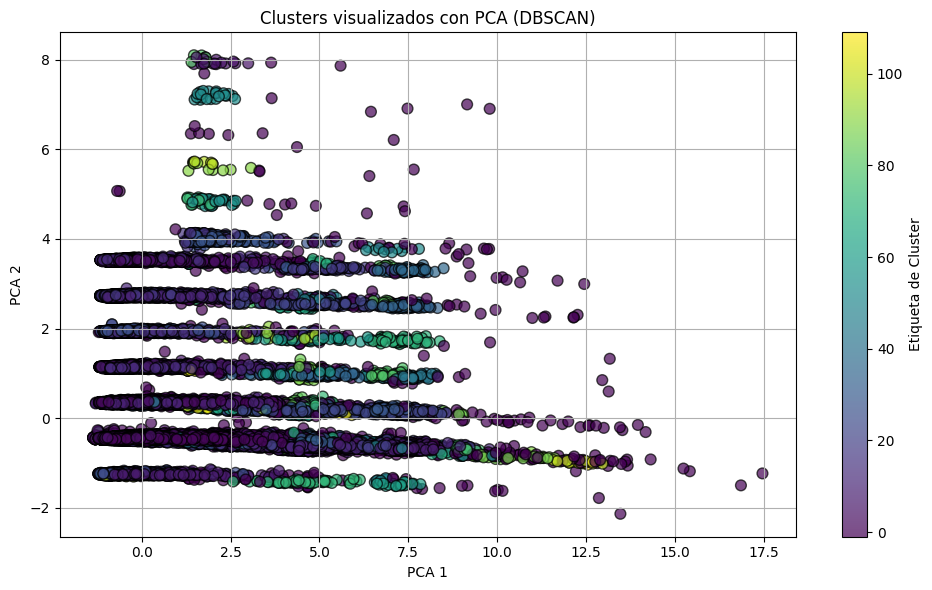

In [ ]:
# Aplicar PCA para reducir a 2 dimensiones solo para visualizar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

# Visualizar los clusters con colores según etiquetas de DBSCAN
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=labels_final, cmap='viridis', s=60, alpha=0.7, edgecolors='k')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Clusters visualizados con PCA (DBSCAN)')
plt.colorbar(scatter, label='Etiqueta de Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()



**Davies - Bouldin**

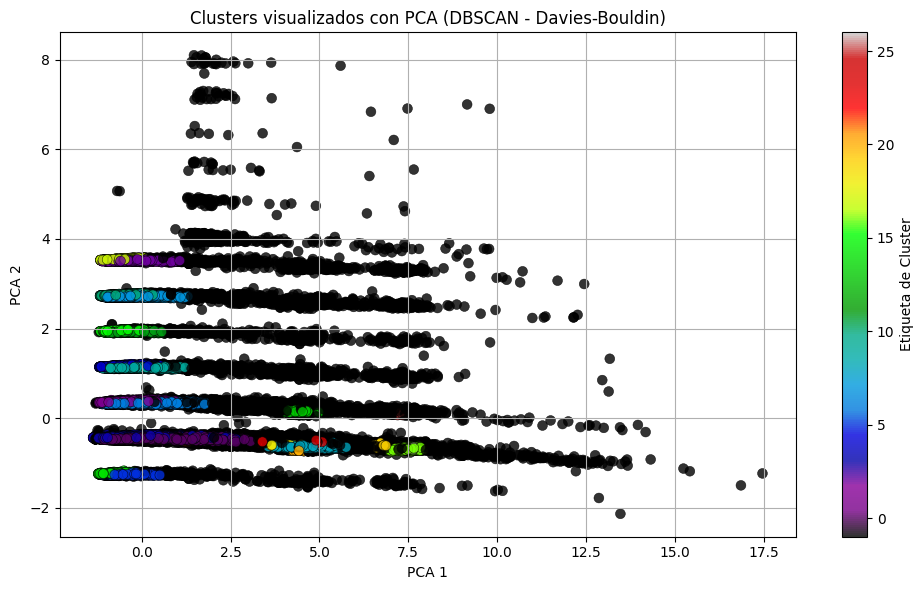

In [ ]:
# Reducir dimensionalidad para visualización
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

# Graficar con colores según etiquetas
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=labels_dbscan_davies,  # asegúrate que esto contenga las etiquetas correctas
    cmap='nipy_spectral',    # puedes cambiar por 'tab20', 'tab10', 'hsv', etc.
    s=50, alpha=0.8, edgecolors='k', linewidth=0.4
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Clusters visualizados con PCA (DBSCAN - Davies-Bouldin)')
cbar = plt.colorbar(scatter, label='Etiqueta de Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

**Calinski - Harabasz**

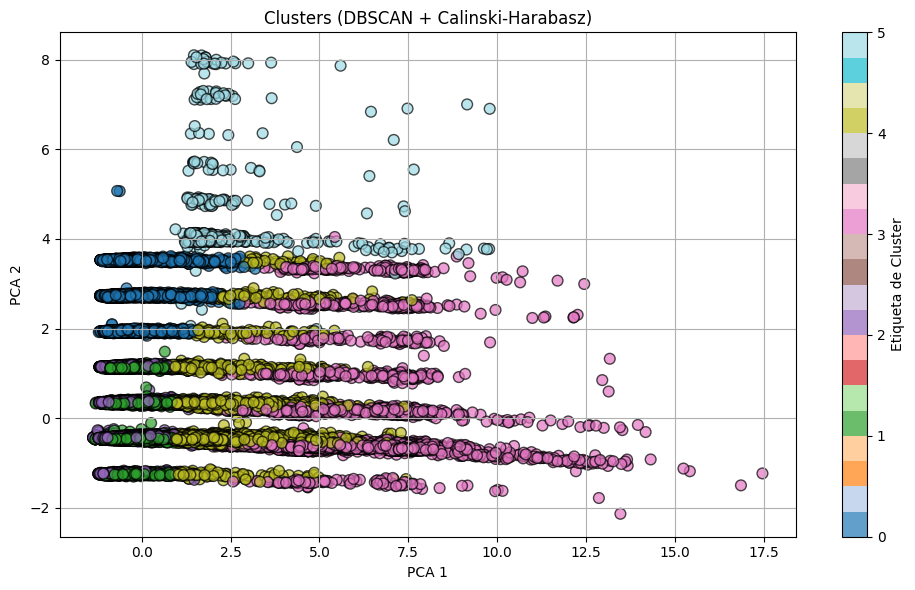

In [ ]:
# Reducimos a 2D para visualización
pca = PCA(n_components=2)
X_pca_ch = pca.fit_transform(X_sample)

# Visualizar
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca_ch[:, 0], X_pca_ch[:, 1],
                      c=labels_ch, cmap='tab20', s=60, alpha=0.7, edgecolors='k')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Clusters (DBSCAN + Calinski-Harabasz)')
plt.colorbar(scatter, label='Etiqueta de Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

## BIRCH

### Silhouette

In [10]:
# Definir el grid de parámetros
param_grid = {
    'n_clusters': [2, 3, 4, 5],
    'threshold': [0.1, 0.3, 0.5],
    'branching_factor': [25, 50, 75]
}

# Modelo base
birch = Birch()

# Función de scoring con Silhouette
def silhouette_scorer(estimator, X):
    labels = estimator.fit_predict(X)
    if len(np.unique(labels)) < 2:  # Silhouette no es válido con 1 solo cluster
        return -1
    return silhouette_score(X, labels)

# GridSearchCV
grid_search = GridSearchCV(birch, param_grid, cv=3, scoring=silhouette_scorer)

print(" Buscando mejores parámetros para BIRCH usando Silhouette Score...")

grid_search.fit(X_sample)

# Resultados
results = []
for i in range(len(grid_search.cv_results_['params'])):
    params = grid_search.cv_results_['params'][i]
    mean_silhouette = grid_search.cv_results_['mean_test_score'][i]
    duration = grid_search.cv_results_['mean_fit_time'][i] + grid_search.cv_results_['mean_score_time'][i]
    results.append((params, mean_silhouette, duration))
    print(f"Parámetros: {params}, Score Promedio (Silhouette): {mean_silhouette:.4f}, Tiempo: {duration:.2f} segundos")

# Mostrar mejores parámetros
print("\n Mejores parámetros encontrados:")
print(grid_search.best_params_)

 Buscando mejores parámetros para BIRCH usando Silhouette Score...
Parámetros: {'branching_factor': 25, 'n_clusters': 2, 'threshold': 0.1}, Score Promedio (Silhouette): 0.8857, Tiempo: 22.01 segundos
Parámetros: {'branching_factor': 25, 'n_clusters': 2, 'threshold': 0.3}, Score Promedio (Silhouette): 0.8857, Tiempo: 21.60 segundos
Parámetros: {'branching_factor': 25, 'n_clusters': 2, 'threshold': 0.5}, Score Promedio (Silhouette): 0.8856, Tiempo: 20.93 segundos
Parámetros: {'branching_factor': 25, 'n_clusters': 3, 'threshold': 0.1}, Score Promedio (Silhouette): 0.7236, Tiempo: 21.88 segundos
Parámetros: {'branching_factor': 25, 'n_clusters': 3, 'threshold': 0.3}, Score Promedio (Silhouette): 0.7236, Tiempo: 21.17 segundos
Parámetros: {'branching_factor': 25, 'n_clusters': 3, 'threshold': 0.5}, Score Promedio (Silhouette): 0.7223, Tiempo: 20.70 segundos
Parámetros: {'branching_factor': 25, 'n_clusters': 4, 'threshold': 0.1}, Score Promedio (Silhouette): 0.5739, Tiempo: 21.69 segundos
Pa

In [20]:
# Recuperar los mejores parámetros del grid anterior
best_params_silhouette = grid_search.best_params_

# Crear y entrenar modelo final
birch_silhouette = Birch(**best_params_silhouette)
labels_birch_silhouette = birch_silhouette.fit_predict(X_sample)

# Calcular métricas
silhouette_birch = silhouette_score(X_sample, labels_birch_silhouette)
davies_bouldin_birch = davies_bouldin_score(X_sample, labels_birch_silhouette)
calinski_harabasz_birch = calinski_harabasz_score(X_sample, labels_birch_silhouette)

# Mostrar resultados
print("\n Métricas del modelo BIRCH (opt. Silhouette):")
print(f"Silhouette Score: {silhouette_birch:.4f}")
print(f"Davies-Bouldin Score: {davies_bouldin_birch:.4f}")
print(f"Calinski-Harabasz Score: {calinski_harabasz_birch:.4f}")


 Métricas del modelo BIRCH (opt. Silhouette):
Silhouette Score: 0.8052
Davies-Bouldin Score: 0.3467
Calinski-Harabasz Score: 20138.0672


### Davies - Bouldin

In [8]:
param_grid = {
    'n_clusters': [2, 3, 4, 5],
    'threshold': [0.1, 0.3, 0.5],
    'branching_factor': [25, 50, 75]
}

# MODELO BASE
birch = Birch()

def negative_davies_bouldin(estimator, X):
    labels = estimator.fit_predict(X)
    score = davies_bouldin_score(X, labels)
    return -score  # GridSearch maximiza, así que usamos negativo

# GRILLA
grid_search = GridSearchCV(birch, param_grid, cv=3, scoring=negative_davies_bouldin)

print(" Buscando mejores parámetros para BIRCH...")

grid_search.fit(X_sample)

# IMPRIMIR LOS RESULTADOS
results = []
for i in range(len(grid_search.cv_results_['params'])):
    params = grid_search.cv_results_['params'][i]
    mean_neg_db = grid_search.cv_results_['mean_test_score'][i]
    duration = grid_search.cv_results_['mean_fit_time'][i] + grid_search.cv_results_['mean_score_time'][i]
    results.append((params, mean_neg_db, duration))
    print(f"Parámetros: {params}, Score Promedio (neg_Davies-Bouldin): {mean_neg_db:.4f}, Tiempo: {duration:.2f} segundos")

# -----------------------------
# Mejor resultado
# -----------------------------
print("\n Mejores parámetros encontrados:")
print(grid_search.best_params_)

 Buscando mejores parámetros para BIRCH...
Parámetros: {'branching_factor': 25, 'n_clusters': 2, 'threshold': 0.1}, Score Promedio (neg_Davies-Bouldin): -0.2036, Tiempo: 3.41 segundos
Parámetros: {'branching_factor': 25, 'n_clusters': 2, 'threshold': 0.3}, Score Promedio (neg_Davies-Bouldin): -0.2036, Tiempo: 2.47 segundos
Parámetros: {'branching_factor': 25, 'n_clusters': 2, 'threshold': 0.5}, Score Promedio (neg_Davies-Bouldin): -0.2048, Tiempo: 2.17 segundos
Parámetros: {'branching_factor': 25, 'n_clusters': 3, 'threshold': 0.1}, Score Promedio (neg_Davies-Bouldin): -0.4512, Tiempo: 3.31 segundos
Parámetros: {'branching_factor': 25, 'n_clusters': 3, 'threshold': 0.3}, Score Promedio (neg_Davies-Bouldin): -0.4512, Tiempo: 2.47 segundos
Parámetros: {'branching_factor': 25, 'n_clusters': 3, 'threshold': 0.5}, Score Promedio (neg_Davies-Bouldin): -0.4603, Tiempo: 2.20 segundos
Parámetros: {'branching_factor': 25, 'n_clusters': 4, 'threshold': 0.1}, Score Promedio (neg_Davies-Bouldin): -

In [19]:
# Obtener mejores parámetros encontrados
best_params_davies = grid_search.best_params_

# Crear y entrenar el modelo final
birch_davies = Birch(**best_params_davies)
labels_birch_davies = birch_davies.fit_predict(X_sample)

# Calcular métricas de evaluación
silhouette_birch = silhouette_score(X_sample, labels_birch_davies)
davies_bouldin_birch = davies_bouldin_score(X_sample, labels_birch_davies)
calinski_harabasz_birch = calinski_harabasz_score(X_sample, labels_birch_davies)

# Mostrar resultados
print("\n Métricas del modelo BIRCH (opt. Davies-Bouldin):")
print(f"Silhouette Score: {silhouette_birch:.4f}")
print(f"Davies-Bouldin Score: {davies_bouldin_birch:.4f}")
print(f"Calinski-Harabasz Score: {calinski_harabasz_birch:.4f}")


 Métricas del modelo BIRCH (opt. Davies-Bouldin):
Silhouette Score: 0.8052
Davies-Bouldin Score: 0.3467
Calinski-Harabasz Score: 20138.0672


### Calinski-Harabasz

In [12]:
# Definir el grid de parámetros
param_grid = {
    'n_clusters': [2, 3, 4, 5],
    'threshold': [0.1, 0.3, 0.5],
    'branching_factor': [25, 50, 75]
}

# Modelo base
birch = Birch()

# Función de scoring con Calinski-Harabasz
def calinski_harabasz_scorer(estimator, X):
    labels = estimator.fit_predict(X)
    if len(np.unique(labels)) < 2:
        return -1  # No es válido para un solo cluster
    return calinski_harabasz_score(X, labels)

# GridSearchCV
grid_search = GridSearchCV(birch, param_grid, cv=3, scoring=calinski_harabasz_scorer)

print(" Buscando mejores parámetros para BIRCH usando Calinski-Harabasz Score...")

grid_search.fit(X_sample)

# Resultados
results = []
for i in range(len(grid_search.cv_results_['params'])):
    params = grid_search.cv_results_['params'][i]
    mean_ch = grid_search.cv_results_['mean_test_score'][i]
    duration = grid_search.cv_results_['mean_fit_time'][i] + grid_search.cv_results_['mean_score_time'][i]
    results.append((params, mean_ch, duration))
    print(f"Parámetros: {params}, Score Promedio (Calinski-Harabasz): {mean_ch:.4f}, Tiempo: {duration:.2f} segundos")

# Mostrar mejores parámetros
print("\n Mejores parámetros encontrados:")
print(grid_search.best_params_)


 Buscando mejores parámetros para BIRCH usando Calinski-Harabasz Score...
Parámetros: {'branching_factor': 25, 'n_clusters': 2, 'threshold': 0.1}, Score Promedio (Calinski-Harabasz): 10650.5810, Tiempo: 3.33 segundos
Parámetros: {'branching_factor': 25, 'n_clusters': 2, 'threshold': 0.3}, Score Promedio (Calinski-Harabasz): 10650.5810, Tiempo: 2.49 segundos
Parámetros: {'branching_factor': 25, 'n_clusters': 2, 'threshold': 0.5}, Score Promedio (Calinski-Harabasz): 10652.9281, Tiempo: 2.21 segundos
Parámetros: {'branching_factor': 25, 'n_clusters': 3, 'threshold': 0.1}, Score Promedio (Calinski-Harabasz): 26203.2474, Tiempo: 3.30 segundos
Parámetros: {'branching_factor': 25, 'n_clusters': 3, 'threshold': 0.3}, Score Promedio (Calinski-Harabasz): 26203.2474, Tiempo: 2.48 segundos
Parámetros: {'branching_factor': 25, 'n_clusters': 3, 'threshold': 0.5}, Score Promedio (Calinski-Harabasz): 26095.0743, Tiempo: 2.19 segundos
Parámetros: {'branching_factor': 25, 'n_clusters': 4, 'threshold': 0

In [21]:
# Obtener los mejores parámetros del grid anterior
best_params_ch = grid_search.best_params_

# Crear y ajustar el modelo final
birch_ch = Birch(**best_params_ch)
labels_birch_ch = birch_ch.fit_predict(X_sample)

# Calcular métricas de evaluación
silhouette_birch = silhouette_score(X_sample, labels_birch_ch)
davies_bouldin_birch = davies_bouldin_score(X_sample, labels_birch_ch)
calinski_harabasz_birch = calinski_harabasz_score(X_sample, labels_birch_ch)

# Mostrar resultados
print("\n Métricas del modelo BIRCH (opt. Calinski-Harabasz):")
print(f"Silhouette Score: {silhouette_birch:.4f}")
print(f"Davies-Bouldin Score: {davies_bouldin_birch:.4f}")
print(f"Calinski-Harabasz Score: {calinski_harabasz_birch:.4f}")


 Métricas del modelo BIRCH (opt. Calinski-Harabasz):
Silhouette Score: 0.8052
Davies-Bouldin Score: 0.3467
Calinski-Harabasz Score: 20138.0672


### Visualización Clusters BIRCH

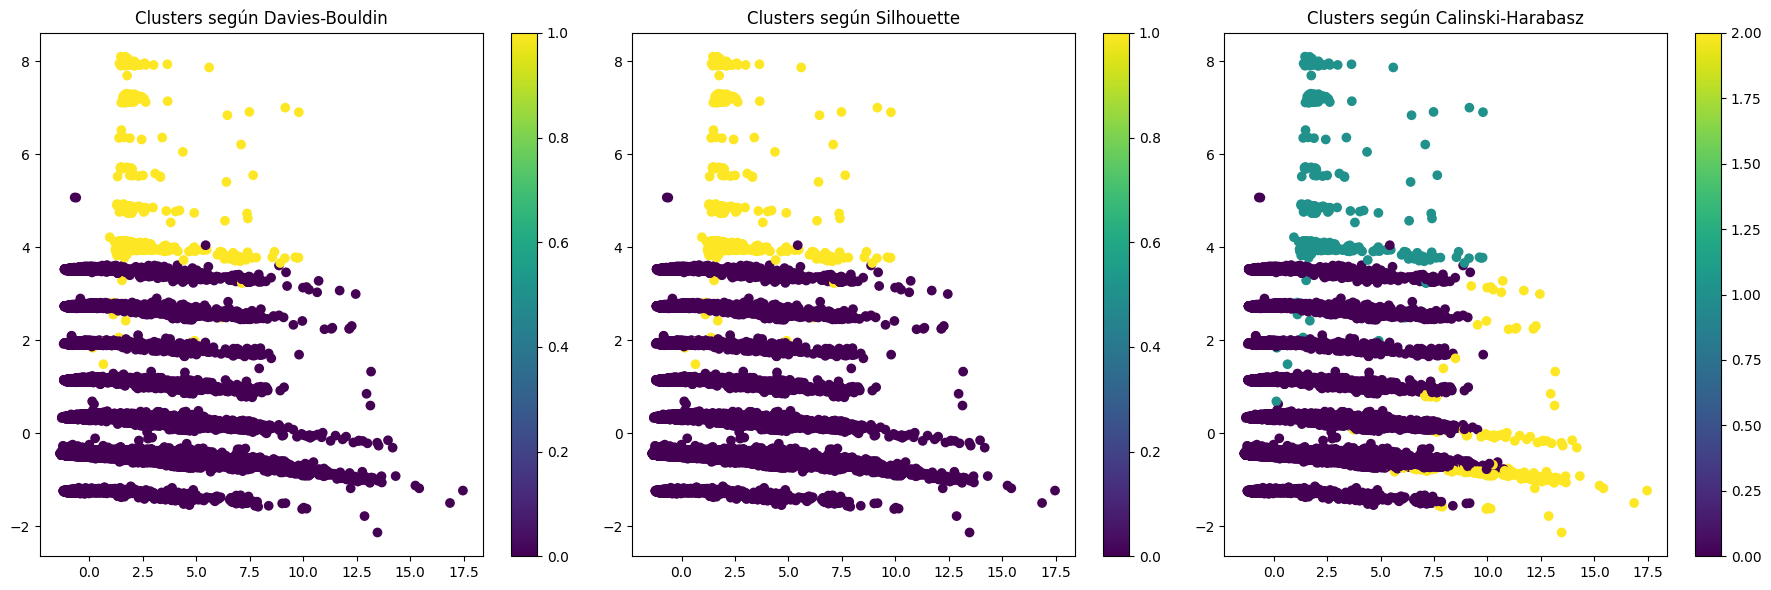

In [27]:
# Función para hacer los gráficos
def plot_clusters(X, labels, ax, title):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', marker='o')
    ax.set_title(title)
    # Añadir colorbar a la figura (no al ax directamente)
    fig.colorbar(scatter, ax=ax)

# Crear una figura con 3 subgráficos (1 fila, 3 columnas)
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# 1. Visualizar los clusters para el modelo Davies-Bouldin
best_params_db = {'n_clusters': 2, 'branching_factor': 25, 'threshold': 0.1}
birch_db = Birch(**best_params_db)
labels_db = birch_db.fit_predict(X_sample)
plot_clusters(X_sample, labels_db, axs[0], "Clusters según Davies-Bouldin")

# 2. Visualizar los clusters para el modelo Silhouette
best_params_sil = {'n_clusters': 2, 'branching_factor': 25, 'threshold': 0.1}
birch_sil = Birch(**best_params_sil)
labels_sil = birch_sil.fit_predict(X_sample)
plot_clusters(X_sample, labels_sil, axs[1], "Clusters según Silhouette")

# 3. Visualizar los clusters para el modelo Calinski-Harabasz
best_params_ch = {'n_clusters': 3, 'branching_factor': 50, 'threshold': 0.5}
birch_ch = Birch(**best_params_ch)
labels_ch = birch_ch.fit_predict(X_sample)
plot_clusters(X_sample, labels_ch, axs[2], "Clusters según Calinski-Harabasz")

# Mostrar el lienzo con los 3 gráficos
plt.tight_layout()
plt.show()

## Gaussian Mixture Model (GMM)

In [ ]:
# %% ======================== MODELO GMM ========================
# Hiperparámetros
param_grid = {
    'n_components': range(2, 11),
    'covariance_type': ['full', 'tied', 'diag', 'spherical'],
    'init_params': ['kmeans', 'random']
}

# Configuración
results = []
best_score = -1
best_model = None
grid = ParameterGrid(param_grid)

# Entrenamiento
start_total = time.time()

for params in tqdm(grid, desc="GMM - Progreso"):
    try:
        model = GaussianMixture(**params, random_state=42)
        labels = model.fit_predict(X)  # Usar X directamente

        if len(np.unique(labels)) < 2:
            continue

        # Calcular métricas
        sil = silhouette_score(X, labels)
        results.append({
            **params,
            'silhouette': sil,
            'davies_bouldin': davies_bouldin_score(X, labels),
            'calinski_harabasz': calinski_harabasz_score(X, labels),
            'n_clusters': len(np.unique(labels))
        })

        # Actualizar mejor modelo
        if sil > best_score:
            best_score = sil
            best_model = model
            with open('best_gmm_model.pkl', 'wb') as f:
                pickle.dump(best_model, f)

    except Exception as e:
        print(f"Error en {params}: {str(e)}")
        continue

# Resultados finales
if best_model:
    clusters = best_model.predict(X)
    X_clustered = X.copy()
    X_clustered['cluster'] = clusters
    X_clustered.to_pickle('clustered_data_gmm.pkl')

    print("\n🔍 Resumen por cluster:")
    print(X_clustered.groupby('cluster').mean())

pd.DataFrame(results).to_csv('gmm_final_results.csv', index=False)
print(f"\n⏱ Tiempo total: {time.time()-start_total:.2f} segundos")

In [ ]:
gmm_results = pd.read_csv('gmm_results.csv')

# %% ------------------------ SELECCIÓN DE MEJORES HIPERPARÁMETROS ------------------------
# 1. Mejor Silhouette (mayor valor)
best_sil_gmm = gmm_results.loc[gmm_results['silhouette'].idxmax()]

# 2. Mejor Davies-Bouldin (menor valor)
best_db_gmm = gmm_results.loc[gmm_results['davies_bouldin'].idxmin()]

# 3. Mejor Calinski-Harabasz (mayor valor)
best_ch_gmm = gmm_results.loc[gmm_results['calinski_harabasz'].idxmax()]

# %% ------------------------ GENERAR REPORTE ------------------------
print("🔥 Modelos Óptimos GMM por Métrica:")
print("\n=== Silhouette ===")
print(f"• Parámetros: covariance_type={best_sil_gmm['covariance_type']}, init_params={best_sil_gmm['init_params']}")
print(f"  n_components={best_sil_gmm['n_components']}")
print(f"• Métricas: Silhouette={best_sil_gmm['silhouette']:.3f}, Davies={best_sil_gmm['davies_bouldin']:.3f}, Calinski={best_sil_gmm['calinski_harabasz']:.1f}")

print("\n=== Davies-Bouldin ===")
print(f"• Parámetros: covariance_type={best_db_gmm['covariance_type']}, init_params={best_db_gmm['init_params']}")
print(f"  n_components={best_db_gmm['n_components']}")
print(f"• Métricas: Silhouette={best_db_gmm['silhouette']:.3f}, Davies={best_db_gmm['davies_bouldin']:.3f}, Calinski={best_db_gmm['calinski_harabasz']:.1f}")

print("\n=== Calinski-Harabasz ===")
print(f"• Parámetros: covariance_type={best_ch_gmm['covariance_type']}, init_params={best_ch_gmm['init_params']}")
print(f"  n_components={best_ch_gmm['n_components']}")
print(f"• Métricas: Silhouette={best_ch_gmm['silhouette']:.3f}, Davies={best_ch_gmm['davies_bouldin']:.3f}, Calinski={best_ch_gmm['calinski_harabasz']:.1f}")

# %% ------------------------ GUARDAR PARÁMETROS ÓPTIMOS ------------------------
best_params_gmm = {
    'silhouette': best_sil_gmm[['covariance_type', 'init_params', 'n_components']].to_dict(),
    'davies_bouldin': best_db_gmm[['covariance_type', 'init_params', 'n_components']].to_dict(),
    'calinski_harabasz': best_ch_gmm[['covariance_type', 'init_params', 'n_components']].to_dict()
}

pd.DataFrame(best_params_gmm).to_csv('optimal_gmm_parameters.csv', index=False)
print("\n✅ Parámetros óptimos GMM guardados en: optimal_gmm_parameters.csv")

🔥 Modelos Óptimos GMM por Métrica:

=== Silhouette ===
• Parámetros: covariance_type=full, init_params=random
  n_components=2
• Métricas: Silhouette=0.813, Davies=1.983, Calinski=13088.3

=== Davies-Bouldin ===
• Parámetros: covariance_type=tied, init_params=kmeans
  n_components=10
• Métricas: Silhouette=0.649, Davies=0.417, Calinski=69386.5

=== Calinski-Harabasz ===
• Parámetros: covariance_type=tied, init_params=kmeans
  n_components=10
• Métricas: Silhouette=0.649, Davies=0.417, Calinski=69386.5

✅ Parámetros óptimos GMM guardados en: optimal_gmm_parameters.csv


In [ ]:
# Parámetros óptimos para cada métrica
parametros_optimos = {
    "silhouette": {
        "n_components": 2,
        "covariance_type": "full",
        "init_params": "random"
    },
    "davies_bouldin": {
        "n_components": 10,
        "covariance_type": "tied",
        "init_params": "kmeans"
    },
    "calinski_harabasz": {
        "n_components": 10,
        "covariance_type": "tied",
        "init_params": "kmeans"
    }
}

# Entrenar y guardar modelos óptimos según cada métrica
for nombre_metrica, params in parametros_optimos.items():
    print(f"\n▶ Entrenando modelo óptimo para {nombre_metrica}...")
    modelo = GaussianMixture(**params, random_state=42)
    modelo.fit(X_sample)

    # Guardar modelo entrenado
    nombre_archivo = f"best_gmm_{nombre_metrica}.pkl"
    with open(nombre_archivo, "wb") as f:
        pickle.dump(modelo, f)

    print(f"✅ Modelo guardado como '{nombre_archivo}'")



▶ Entrenando modelo óptimo para silhouette...
✅ Modelo guardado como 'best_gmm_silhouette.pkl'

▶ Entrenando modelo óptimo para davies_bouldin...
✅ Modelo guardado como 'best_gmm_davies_bouldin.pkl'

▶ Entrenando modelo óptimo para calinski_harabasz...
✅ Modelo guardado como 'best_gmm_calinski_harabasz.pkl'


In [ ]:
# ------------------------------------------------
# 2. Rutas de tus modelos GMM
# ------------------------------------------------
model_paths = {
    "silhouette":         "best_gmm_silhouette.pkl",
    "davies_bouldin":     "best_gmm_davies_bouldin.pkl",
    "calinski_harabasz":  "best_gmm_calinski_harabasz.pkl"
}

# ------------------------------------------------
# 3. Cargar cada modelo y predecir clusters
# ------------------------------------------------
labels_dict = {}
for metric, path in model_paths.items():
    with open(path, "rb") as f:
        gmm = pickle.load(f)
    # Usamos .predict() porque el modelo ya está entrenado
    labels = gmm.predict(X_sample)
    labels_dict[f"cluster_{metric}"] = labels

# ------------------------------------------------
# 4. Construir DataFrame de etiquetas y unirlo a X_sample
# ------------------------------------------------
df_labels = pd.DataFrame(labels_dict, index=X_sample.index)
df_full   = pd.concat([X_sample, df_labels], axis=1)

# ------------------------------------------------
# 5. Ver distribuciones de clusters (normalize=True)
# ------------------------------------------------
for metric in model_paths:
    col = f"cluster_{metric}"
    print(f"\nDistribución (normalizada) de {col}:")
    print(df_full[col].value_counts(normalize=True).sort_index())

# ------------------------------------------------
# 6. Guardar a CSV
# ------------------------------------------------
df_full.to_csv("clusters_gmm_sample.csv", index=False)
print("\n✅ Etiquetas de cluster añadidas y guardadas en 'clusters_gmm_sample.csv'")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GaussianMixture was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GaussianMixture was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GaussianMixture was fitted without feature names
  warnings.warn(



Distribución (normalizada) de cluster_silhouette:
cluster_silhouette
0    0.035173
1    0.964827
Name: proportion, dtype: float64

Distribución (normalizada) de cluster_davies_bouldin:
cluster_davies_bouldin
0    0.056733
1    0.017593
2    0.002547
3    0.609080
4    0.243180
5    0.006027
6    0.029593
7    0.024900
8    0.005147
9    0.005200
Name: proportion, dtype: float64

Distribución (normalizada) de cluster_calinski_harabasz:
cluster_calinski_harabasz
0    0.056733
1    0.017593
2    0.002547
3    0.609080
4    0.243180
5    0.006027
6    0.029593
7    0.024900
8    0.005147
9    0.005200
Name: proportion, dtype: float64

✅ Etiquetas de cluster añadidas y guardadas en 'clusters_gmm_sample.csv'


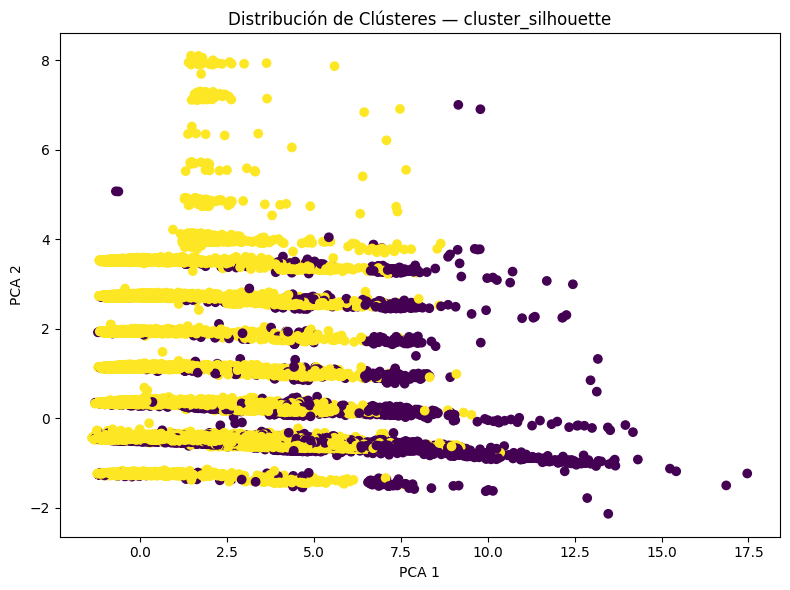

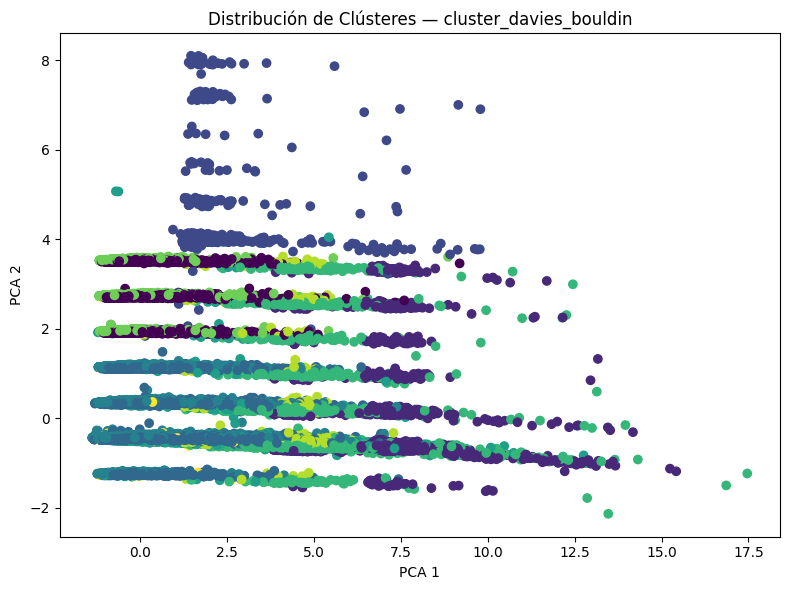

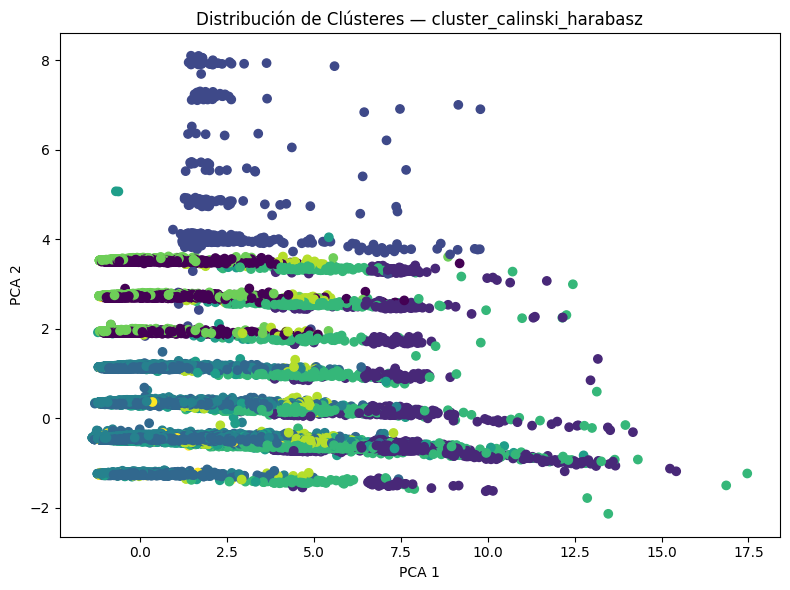

In [ ]:
# El CSV con las etiquetas de clusters 
df_clusters = pd.read_csv("clusters_gmm_sample.csv")

# -----------------------------
# 2. Aplicar PCA a 2 dimensiones
# -----------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
# Adjuntar solo las tres columnas de cluster
pca_df = pd.concat([
    pca_df,
    df_clusters[['cluster_silhouette', 'cluster_davies_bouldin', 'cluster_calinski_harabasz']]
], axis=1)

# -----------------------------
# 3. Graficar con matplotlib
# -----------------------------
for metric in ['cluster_silhouette', 'cluster_davies_bouldin', 'cluster_calinski_harabasz']:
    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(
        pca_df['PCA1'], pca_df['PCA2'],
        c=pca_df[metric]  # colores automáticos según etiqueta
    )
    ax.set_title(f"Distribución de Clústeres — {metric}")
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    plt.tight_layout()
    plt.show()


## Model Mean Shift (MS)

In [ ]:
# %% ======================== MODELO MEAN SHIFT ========================

# Estimación de bandwidth adaptativo
bandwidth = estimate_bandwidth(X, quantile=0.25, n_samples=2000)  # Usar X directamente
bandwidths = np.round([
    bandwidth * factor
    for factor in [0.7, 1.0, 1.3, 1.7]
], 3).tolist()

# Hiperparámetros
param_grid = {
    'bandwidth': bandwidths,
    'cluster_all': [True, False],
    'bin_seeding': [True, False],
    'min_bin_freq': [5, 10]
}

# Entrenamiento
results = []
best_score = -1
grid = ParameterGrid(param_grid)

start_total = time.time()

for params in tqdm(grid, desc="Mean Shift - Progreso"):
    try:
        model = MeanShift(**params, n_jobs=-1)
        labels = model.fit_predict(X)  # Entrenar con X

        if len(np.unique(labels)) < 2:
            continue

        # Calcular métricas
        sil = silhouette_score(X, labels)
        results.append({
            **params,
            'silhouette': sil,
            'n_clusters': len(np.unique(labels)),
            'davies_bouldin': davies_bouldin_score(X, labels),
            'calinski_harabasz': calinski_harabasz_score(X, labels)
        })

        # Actualizar mejor modelo
        if sil > best_score:
            best_score = sil
            best_model = model
            with open('best_meanshift_model.pkl', 'wb') as f:
                pickle.dump(best_model, f)

    except Exception as e:
        print(f"Error en {params}: {str(e)}")
        continue

# Resultados finales
if best_score != -1:
    clusters = best_model.labels_
    X_clustered = X.copy()
    X_clustered['cluster'] = clusters
    X_clustered.to_pickle('clustered_data_meanshift.pkl')

    print("\n🔍 Distribución de clusters:")
    print(X_clustered['cluster'].value_counts().sort_index())

    print("\n📊 Métricas:")
    print(f"Silhouette: {best_score:.3f}")
    print(f"Davies-Bouldin: {results[0]['davies_bouldin']:.3f}")  # Ejemplo

pd.DataFrame(results).to_csv('meanshift_results.csv', index=False)
print(f"\n⏱ Tiempo total: {time.time() - start_total:.2f} segundos")

In [ ]:
# Parámetros óptimos para cada métrica
parametros_meanshift = {
    "silhouette": {
        "bandwidth": 10,
        "bin_seeding": True,
        "cluster_all": True
    },
    "davies_bouldin": {
        "bandwidth": 5,
        "bin_seeding": False,
        "cluster_all": False
    },
    "calinski_harabasz": {
        "bandwidth": 10,
        "bin_seeding": True,
        "cluster_all": True
    }
}

# Entrenar y guardar modelos por cada métrica
for nombre_metrica, params in parametros_meanshift.items():
    print(f"\n▶ Entrenando modelo óptimo para {nombre_metrica}...")
    modelo = MeanShift(**params)
    modelo.fit(X_sample)

    # Guardar modelo
    nombre_archivo = f"best_meanshift_{nombre_metrica}.pkl"
    with open(nombre_archivo, "wb") as f:
        pickle.dump(modelo, f)

    print(f"✅ Modelo guardado como '{nombre_archivo}'")


In [ ]:
# ------------------------------------------------
# 1. Rutas de tus modelos MeanShift
# ------------------------------------------------
model_paths = {
    "silhouette":         "best_meanshift_silhouette.pkl",
    "davies_bouldin":     "best_meanshift_davies_bouldin.pkl",
    "calinski_harabasz":  "best_meanshift_calinski_harabasz.pkl"
}

# ------------------------------------------------
# 2. Cargar cada modelo y predecir clusters
# ------------------------------------------------
labels_dict = {}
for metric, path in model_paths.items():
    with open(path, "rb") as f:
        ms = pickle.load(f)
    # Usamos .predict() porque el modelo ya está entrenado
    labels = ms.predict(X_sample)
    labels_dict[f"cluster_{metric}"] = labels

# ------------------------------------------------
# 3. Construir DataFrame de etiquetas y unirlo a X_sample
# ------------------------------------------------
df_labels = pd.DataFrame(labels_dict, index=X_sample.index)
df_full   = pd.concat([X_sample, df_labels], axis=1)

# ------------------------------------------------
# 4. Ver distribuciones de clusters (normalize=True)
# ------------------------------------------------
for metric in model_paths:
    col = f"cluster_{metric}"
    print(f"\nDistribución (normalizada) de {col}:")
    print(df_full[col].value_counts(normalize=True).sort_index())

# ------------------------------------------------
# 5. Guardar a CSV
# ------------------------------------------------
df_full.to_csv("clusters_meanshift_sample.csv", index=False)
print("\n✅ Etiquetas de cluster añadidas y guardadas en 'clusters_meanshift_sample.csv'")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MeanShift was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MeanShift was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MeanShift was fitted without feature names
  warnings.warn(



Distribución (normalizada) de cluster_silhouette:
cluster_silhouette
0    0.997447
1    0.002553
Name: proportion, dtype: float64

Distribución (normalizada) de cluster_davies_bouldin:
cluster_davies_bouldin
0    0.975160
1    0.002453
2    0.022220
3    0.000087
4    0.000020
5    0.000007
6    0.000007
7    0.000007
8    0.000033
9    0.000007
Name: proportion, dtype: float64

Distribución (normalizada) de cluster_calinski_harabasz:
cluster_calinski_harabasz
0    0.997447
1    0.002553
Name: proportion, dtype: float64

✅ Etiquetas de cluster añadidas y guardadas en 'clusters_meanshift_sample.csv'


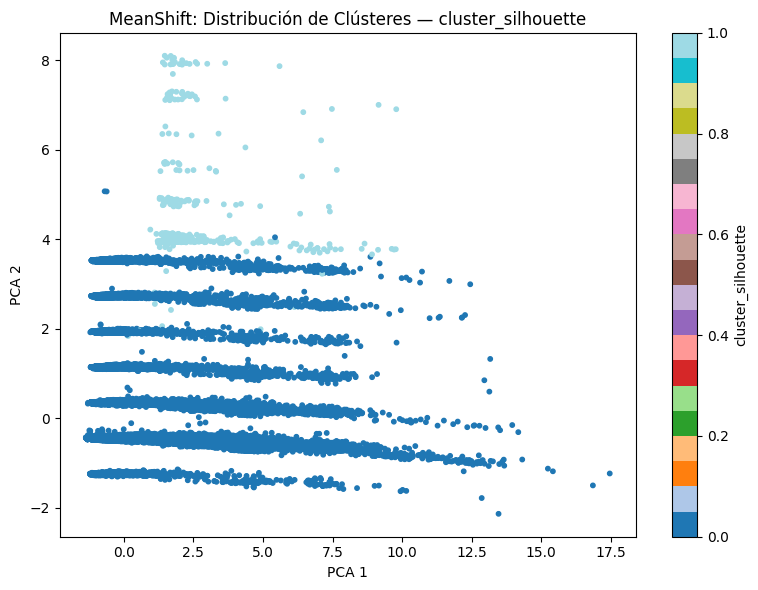

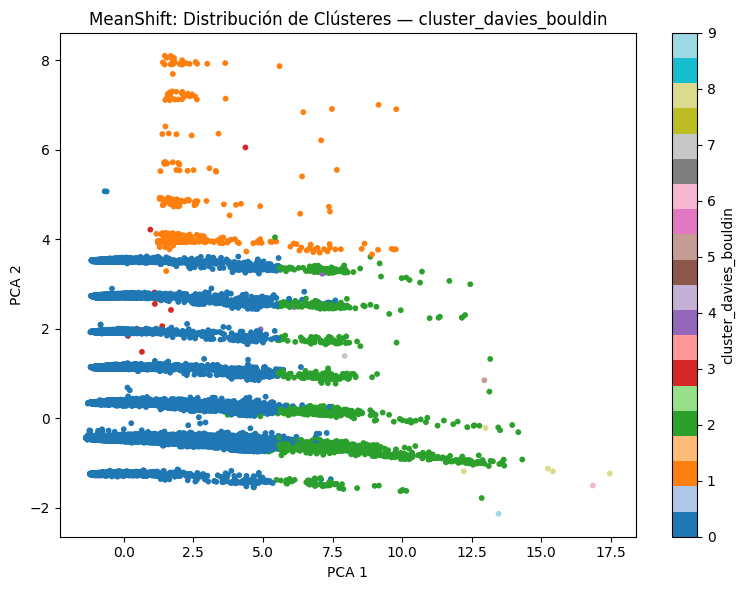

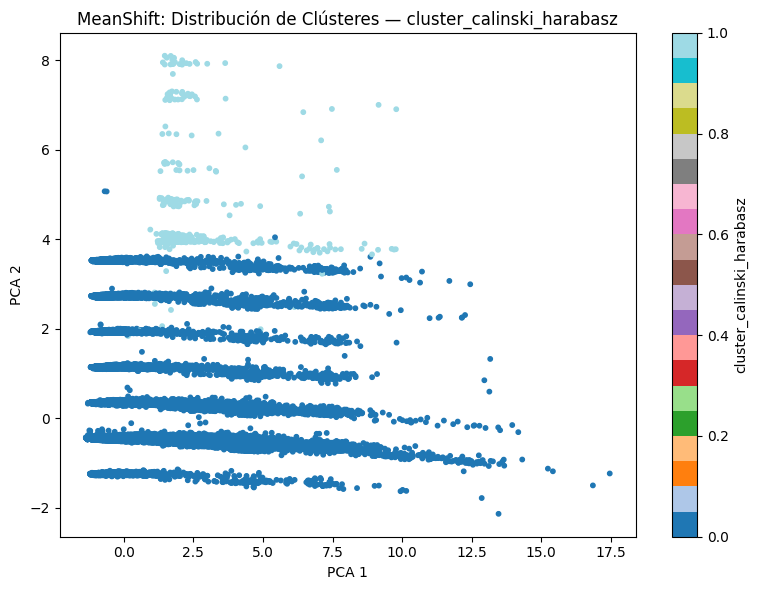

In [ ]:
# -----------------------------
# 1. Cargar las etiquetas (MeanShift)
# CSV con etiquetas de MeanShift
df_clusters_ms = pd.read_csv("clusters_meanshift_sample.csv")

# -----------------------------
# 2. Aplicar PCA a 2 dimensiones
# -----------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
pca_df = pd.concat([
    pca_df,
    df_clusters_ms[['cluster_silhouette', 'cluster_davies_bouldin', 'cluster_calinski_harabasz']]
], axis=1)

# -----------------------------
# 3. Graficar con matplotlib
# -----------------------------
for metric in ['cluster_silhouette', 'cluster_davies_bouldin', 'cluster_calinski_harabasz']:
    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(
        pca_df['PCA1'], pca_df['PCA2'],
        c=pca_df[metric], cmap='tab20', s=10
    )
    ax.set_title(f"MeanShift: Distribución de Clústeres — {metric}")
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    plt.colorbar(scatter, label=metric)
    plt.tight_layout()
    plt.show()


## Self-Organizing Maps (SOM)

In [ ]:
# %% ------------------------ CONFIGURACIÓN DE MODELO ------------------------
params = {
    'som_shape': (10, 10),
    'sigma': 1.0,
    'learning_rate': 0.5,
    'num_epochs': 100,
    'random_seed': 42
}

# %% ------------------------ ENTRENAMIENTO ------------------------
try:
    print("⚙️ Configuración del modelo:")
    print(f"- Tamaño SOM: {params['som_shape'][0]}x{params['som_shape'][1]}")
    print(f"- Sigma: {params['sigma']} | Tasa aprendizaje: {params['learning_rate']}")
    print(f"- Épocas: {params['num_epochs']} | Semilla: {params['random_seed']}\n")

    # Inicializar y entrenar modelo
    som = MiniSom(
        params['som_shape'][0],
        params['som_shape'][1],
        X.shape[1],
        sigma=params['sigma'],
        learning_rate=params['learning_rate'],
        random_seed=params['random_seed']
    )

    print("🚀 Entrenando SOM...")
    start_time = time.time()

    # Barra de progreso mejorada
    with tqdm(total=params['num_epochs'], desc="Progreso", unit="época") as pbar:
        for _ in range(params['num_epochs']):
            som.train_random(X.values, num_iteration=1, verbose=False)
            pbar.update(1)

    train_time = time.time() - start_time

    # Asignación de clusters
    winner_coordinates = np.array([som.winner(x) for x in X.values])
    cluster_ids = winner_coordinates[:, 0] * params['som_shape'][1] + winner_coordinates[:, 1]
    n_clusters = len(np.unique(cluster_ids))

    # Cálculo de métricas
    metrics = {}
    if n_clusters > 1:
        metrics = {
            'silhouette': silhouette_score(X, cluster_ids),
            'davies_bouldin': davies_bouldin_score(X, cluster_ids),
            'calinski_harabasz': calinski_harabasz_score(X, cluster_ids)
        }
    else:
        metrics = {k: np.nan for k in ['silhouette', 'davies_bouldin', 'calinski_harabasz']}

    # Guardar resultados
    results_df = pd.DataFrame([{
        **params,
        **metrics,
        'n_clusters': n_clusters,
        'tiempo_entrenamiento': train_time
    }])

    results_df.to_csv('resultados_SOM.csv', index=False)

    # Guardar artefactos
    X_clustered = X.copy()
    X_clustered['cluster'] = cluster_ids
    X_clustered.to_pickle('datos_clusterizados_SOM.pkl')

    with open('mejor_modelo_SOM.pkl', 'wb') as f:
        pickle.dump(som, f)

    print("\n✅ Entrenamiento completado:")
    print(f"- Tiempo total: {train_time:.2f} segundos")
    print(f"- Clusters detectados: {n_clusters}")
    print(f"📊 Métricas:")
    print(f"   • Silhouette: {metrics['silhouette']:.3f}")
    print(f"   • Davies-Bouldin: {metrics['davies_bouldin']:.3f}")
    print(f"   • Calinski-Harabasz: {metrics['calinski_harabasz']:.1f}")

except Exception as e:
    print(f"\n❌ Error durante el entrenamiento: {str(e)}")
    exit()

# %% ------------------------ ANÁLISIS POST-ENTRENAMIENTO ------------------------
try:
    print("\n🔍 Análisis de clusters:")
    print(X_clustered['cluster'].value_counts().sort_index().to_string(name='Muestras'))

    print("\n📊 Estadísticas por cluster:")
    print(X_clustered.groupby('cluster').mean().T.to_string(float_format="%.2f"))

    print(f"\n💾 Resultados guardados en:")
    print("- results_SOM.csv")
    print("- datos_clusterizados_SOM.pkl")
    print("- mejor_modelo_SOM.pkl")

except Exception as e:
    print(f"\n⚠️ Error en análisis post-entrenamiento: {str(e)}")

⏳ Cargando datos...

✅ Datos cargados correctamente:
Muestras: 150000 | Características: 15
Columnas: ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14']

⚠️ MiniSom no instalado. Instalando...
⚙️ Configuración del modelo:
- Tamaño SOM: 10x10
- Sigma: 1.0 | Tasa aprendizaje: 0.5
- Épocas: 100 | Semilla: 42

🚀 Entrenando SOM...


Progreso: 100%|██████████| 100/100 [00:00<00:00, 6794.38época/s]



✅ Entrenamiento completado:
- Tiempo total: 0.02 segundos
- Clusters detectados: 60
📊 Métricas:
   • Silhouette: 0.072
   • Davies-Bouldin: 1.835
   • Calinski-Harabasz: 4968.1

🔍 Análisis de clusters:
cluster
2        10
3        75
5         6
7         8
9        36
11        1
13        1
14       27
15       84
16      365
17    18450
18      453
21        3
24        4
26       40
27        3
33      129
35      128
36        7
37        1
38       38
39     1044
40      198
41        2
43       32
45    12381
47        2
49        5
50     9908
51     4452
52    51586
53     1441
54      340
56        1
57       24
59        1
60      227
61       15
62        3
64        2
68       96
70     7743
72       13
73    19098
74        2
76        5
78       27
80    19283
81      102
82        1
83        1
86        1
88      124
89        2
90        8
92       11
94     1069
95       33
96      756
97       92
Name: count

📊 Estadísticas por cluster:
cluster       2     3     5 

Distribución de clusters SOM (normalizada):
cluster_SOM
2     0.000067
3     0.000500
5     0.000040
7     0.000053
9     0.000240
11    0.000007
13    0.000007
14    0.000180
15    0.000560
16    0.002433
17    0.123000
18    0.003020
21    0.000020
24    0.000027
26    0.000267
27    0.000020
33    0.000860
35    0.000853
36    0.000047
37    0.000007
38    0.000253
39    0.006960
40    0.001320
41    0.000013
43    0.000213
45    0.082540
47    0.000013
49    0.000033
50    0.066053
51    0.029680
52    0.343907
53    0.009607
54    0.002267
56    0.000007
57    0.000160
59    0.000007
60    0.001513
61    0.000100
62    0.000020
64    0.000013
68    0.000640
70    0.051620
72    0.000087
73    0.127320
74    0.000013
76    0.000033
78    0.000180
80    0.128553
81    0.000680
82    0.000007
83    0.000007
86    0.000007
88    0.000827
89    0.000013
90    0.000053
92    0.000073
94    0.007127
95    0.000220
96    0.005040
97    0.000613
Name: proportion, dtype: float64
✅ 'clusters

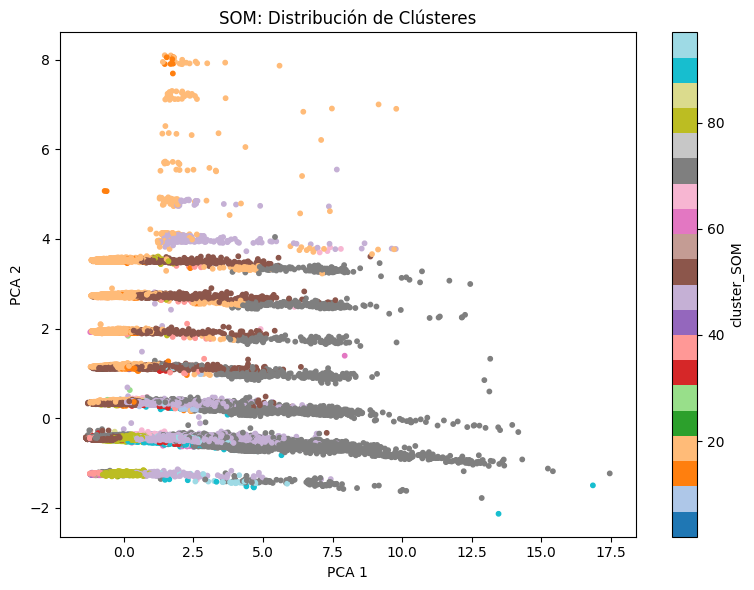

In [ ]:
# -----------------------------
# 1. Cargar el modelo SOM entrenado
# -----------------------------
with open("best_SOM_model.pkl", "rb") as f:
    som_loaded = pickle.load(f)

if isinstance(som_loaded, dict):
    som = som_loaded['model']
else:
    som = som_loaded

# -----------------------------
# 2. Asignar clusters según winners
# -----------------------------
coords = np.array([som.winner(x) for x in X_sample.values])
n_cols = som._weights.shape[1]
cluster_ids = coords[:, 0] * n_cols + coords[:, 1]

# -----------------------------
# 3. Construir DataFrame y mostrar distribución
# -----------------------------
df_full = X_sample.copy()
df_full['cluster_SOM'] = cluster_ids

print("Distribución de clusters SOM (normalizada):")
print(df_full['cluster_SOM'].value_counts(normalize=True).sort_index())

# -----------------------------
# 4. Guardar etiquetas en CSV
# -----------------------------
df_full.to_csv("clusters_SOM_sample.csv", index=False)
print("✅ 'clusters_SOM_sample.csv' guardado.")

# -----------------------------
# 5. PCA y visualización
# -----------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample.values)

pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'], index=X_sample.index)
pca_df['cluster_SOM'] = cluster_ids

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    pca_df['PCA1'], pca_df['PCA2'],
    c=pca_df['cluster_SOM'], cmap='tab20', s=10
)
ax.set_title("SOM: Distribución de Clústeres")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
plt.colorbar(scatter, label='cluster_SOM')
plt.tight_layout()
plt.show()


## HDBSCAN

In [ ]:
def formatear_tiempo(segundos):
    minutos = int(segundos // 60)
    segundos = int(segundos % 60)
    return f"{minutos}m {segundos}s"

### Silhouette

In [ ]:
# Definir la grilla de hiperparámetros
param_grid = {
    'min_cluster_size': [10, 30, 50],
    'min_samples': [10, 20],
    'metric': ['euclidean', 'manhattan']
}

# Intentar cargar resultados parciales
try:
    resultados_parciales = pd.read_csv(resultados_path)
    print("✅ Resultados parciales cargados.")
    iteracion_inicial = len(resultados_parciales)
    mejor_score = resultados_parciales['silhouette'].max()
    mejor_idx = resultados_parciales['silhouette'].idxmax()
    mejor_modelo = pickle.load(open(modelo_path, 'rb'))
except:
    resultados_parciales = []
    iteracion_inicial = 0
    mejor_score = -1
    mejor_modelo = None

# Inicializar timer global
inicio_total = time.time()
total_iteraciones = len(list(ParameterGrid(param_grid)))

# Bucle principal con barra de progreso
with tqdm(total=total_iteraciones, initial=iteracion_inicial, desc="Entrenando HDBSCAN") as pbar:
    for i, params in enumerate(ParameterGrid(param_grid)):
        if i < iteracion_inicial:
            continue  # Saltar ya entrenados

        print(f"▶ Iteración {i+1}/{total_iteraciones} - {params}")
        inicio = time.time()
        modelo = hdbscan.HDBSCAN(**params)
        modelo.fit(X_sample)
        etiquetas = modelo.labels_
        tiempo = round(time.time() - inicio, 2)

        elapsed = time.time() - inicio
        tiempo_total = time.time() - inicio_total

        # Validación: al menos 2 clústeres válidos
        if len(set(etiquetas)) <= 1 or (etiquetas == -1).all():
            print("⚠️ Solo se encontró un clúster o todos son ruido. Se omite esta combinación.")
            sil, db, ch = np.nan, np.nan, np.nan
        else:
            try:
                sil = silhouette_score(X_sample, etiquetas)
            except:
                sil = np.nan

        # Guardar mejor modelo
        if sil > mejor_score:
            mejor_score = sil
            mejor_modelo = modelo
            pickle.dump(mejor_modelo, open("hdbscan_model_final.pkl", "wb"))
            print("✅ Nuevo mejor modelo guardado.")


        # Almacenar resultados parciales
        resultados_parciales.append({
            **params,
            "silhouette": sil,
            "tiempo_iter_s": round(elapsed, 2),
            "tiempo_s": tiempo
        })

        pd.DataFrame(resultados_parciales).to_csv("resultados_parciales_hdbscan.csv", index=False)


        # Mostrar en tiempo real
        pbar.set_postfix({
            "Silhouette": f"{sil:.3f}",
            "Iteración": f"{formatear_tiempo(elapsed)}",
            "Total": f"{formatear_tiempo(time.time() - inicio_total)}"
        })

        print(f"⏱️ Tiempo de esta iteración: {formatear_tiempo(elapsed)}")
        print(f"⏱️ Tiempo total acumulado: {formatear_tiempo(time.time() - inicio_total)}")



pd.DataFrame(resultados_parciales)


Entrenando HDBSCAN:   0%|                                                                       | 0/12 [00:00<?, ?it/s]

▶ Iteración 1/12 - {'metric': 'euclidean', 'min_cluster_size': 10, 'min_samples': 10}



Entrenando HDBSCAN:   0%|                    | 0/12 [06:25<?, ?it/s, Silhouette=-0.267, Iteración=1m 12s, Total=6m 25s]

✅ Nuevo mejor modelo guardado.
⏱️ Tiempo de esta iteración: 1m 12s
⏱️ Tiempo total acumulado: 6m 25s
▶ Iteración 2/12 - {'metric': 'euclidean', 'min_cluster_size': 10, 'min_samples': 20}



Entrenando HDBSCAN:   0%|                   | 0/12 [12:33<?, ?it/s, Silhouette=-0.184, Iteración=1m 17s, Total=12m 33s]

...


Entrenando HDBSCAN:   0%|                 | 0/12 [1:05:42<?, ?it/s, Silhouette=-0.171, Iteración=1m 11s, Total=65m 42s]

⏱️ Tiempo de esta iteración: 1m 11s
⏱️ Tiempo total acumulado: 65m 43s
▶ Iteración 12/12 - {'metric': 'manhattan', 'min_cluster_size': 50, 'min_samples': 20}


Entrenando HDBSCAN:   0%|                  | 0/12 [1:11:11<?, ?it/s, Silhouette=-0.183, Iteración=1m 1s, Total=71m 11s]

⏱️ Tiempo de esta iteración: 1m 1s
⏱️ Tiempo total acumulado: 71m 11s


,metric,min_cluster_size,min_samples,silhouette,tiempo_iter_s,tiempo_s
0,euclidean,10,10,-0.267135,72.70,72.70
1,euclidean,10,20,-0.183518,77.20,77.20
2,euclidean,30,10,-0.177210,79.68,79.68
3,euclidean,30,20,-0.209133,74.97,74.97
4,euclidean,50,10,-0.162844,77.59,77.59
5,euclidean,50,20,0.254351,69.93,69.93
6,manhattan,10,10,-0.301494,83.61,83.61
7,manhattan,10,20,-0.235952,62.91,62.91
8,manhattan,30,10,-0.180631,69.52,69.52
9,manhattan,30,20,-0.219254,63.85,63.85


### Davies - Bouldin 

In [ ]:
# Definir la grilla de hiperparámetros
param_grid = {
    'min_cluster_size': [10, 30, 50],
    'min_samples': [10, 20],
    'metric': ['euclidean', 'manhattan']
}

# Intentar cargar resultados parciales
try:
    resultados_parciales = pd.read_csv(resultados_path)
    print("✅ Resultados parciales cargados.")
    iteracion_inicial = len(resultados_parciales)
    mejor_score = resultados_parciales['davies_bouldin'].min()
    mejor_idx = resultados_parciales['davies_bouldin'].idxmin()
    mejor_modelo = pickle.load(open(modelo_path, 'rb'))
except:
    resultados_parciales = []
    iteracion_inicial = 0
    mejor_score = -1
    mejor_modelo = None

# Inicializar timer global
inicio_total = time.time()
total_iteraciones = len(list(ParameterGrid(param_grid)))

# Bucle principal con barra de progreso
with tqdm(total=total_iteraciones, initial=iteracion_inicial, desc="Entrenando HDBSCAN") as pbar:
    for i, params in enumerate(ParameterGrid(param_grid)):
        if i < iteracion_inicial:
            continue  # Saltar ya entrenados

        print(f"▶ Iteración {i+1}/{total_iteraciones} - {params}")
        inicio = time.time()
        modelo = hdbscan.HDBSCAN(**params)
        modelo.fit(X_sample)
        etiquetas = modelo.labels_
        tiempo = round(time.time() - inicio, 2)

        elapsed = time.time() - inicio
        tiempo_total = time.time() - inicio_total

        # Validación: al menos 2 clústeres válidos
        if len(set(etiquetas)) <= 1 or (etiquetas == -1).all():
            print("⚠️ Solo se encontró un clúster o todos son ruido. Se omite esta combinación.")
            db = np.nan
        else:
            try:
                db = davies_bouldin_score(X_sample, etiquetas)
            except:
                db = np.nan

        # Guardar mejor modelo
        if db < mejor_score or mejor_score == -1:
            mejor_score = db
            mejor_modelo = modelo
            pickle.dump(mejor_modelo, open("hdbscan_model_final_db.pkl", "wb"))
            print("✅ Nuevo mejor modelo guardado.")


        # Almacenar resultados parciales
        resultados_parciales.append({
            **params,
            "davies_bouldin": db,
            "tiempo_iter_s": round(elapsed, 2),
            "tiempo_s": tiempo
        })

        pd.DataFrame(resultados_parciales).to_csv("resultados_parciales_hdbscan_db.csv", index=False)

        print(f"⏱️ Tiempo de esta iteración: {formatear_tiempo(elapsed)}")
        print(f"⏱️ Tiempo total acumulado: {formatear_tiempo(time.time() - inicio_total)}")



pd.DataFrame(resultados_parciales)


Entrenando HDBSCAN:   0%|                                                                       | 0/12 [00:00<?, ?it/s]

▶ Iteración 1/12 - {'metric': 'euclidean', 'min_cluster_size': 10, 'min_samples': 10}
✅ Nuevo mejor modelo guardado.
⏱️ Tiempo de esta iteración: 1m 12s
⏱️ Tiempo total acumulado: 1m 13s
▶ Iteración 2/12 - {'metric': 'euclidean', 'min_cluster_size': 10, 'min_samples': 20}
⏱️ Tiempo de esta iteración: 1m 5s
⏱️ Tiempo total acumulado: 2m 19s
▶ Iteración 3/12 - {'metric': 'euclidean', 'min_cluster_size': 30, 'min_samples': 10}
⏱️ Tiempo de esta iteración: 1m 7s
⏱️ Tiempo total acumulado: 3m 28s
▶ Iteración 4/12 - {'metric': 'euclidean', 'min_cluster_size': 30, 'min_samples': 20}
⏱️ Tiempo de esta iteración: 1m 4s
⏱️ Tiempo total acumulado: 4m 32s
▶ Iteración 5/12 - {'metric': 'euclidean', 'min_cluster_size': 50, 'min_samples': 10}
⏱️ Tiempo de esta iteración: 1m 8s
⏱️ Tiempo total acumulado: 5m 41s
▶ Iteración 6/12 - {'metric': 'euclidean', 'min_cluster_size': 50, 'min_samples': 20}
⏱️ Tiempo de esta iteración: 1m 4s
⏱️ Tiempo total acumulado: 6m 46s
▶ Iteración 7/12 - {'metric': 'manhatt


Entrenando HDBSCAN:   0%|                                                                       | 0/12 [12:56<?, ?it/s]

⏱️ Tiempo de esta iteración: 1m 0s
⏱️ Tiempo total acumulado: 12m 56s


,metric,min_cluster_size,min_samples,davies_bouldin,tiempo_iter_s,tiempo_s
0,euclidean,10,10,1.598389,72.47,72.47
1,euclidean,10,20,1.712387,65.54,65.54
2,euclidean,30,10,1.827837,67.96,67.96
3,euclidean,30,20,1.672745,64.25,64.25
4,euclidean,50,10,1.920436,68.40,68.40
5,euclidean,50,20,1.880606,64.98,64.98
6,manhattan,10,10,1.559594,63.30,63.30
7,manhattan,10,20,1.626352,56.72,56.72
8,manhattan,30,10,1.739717,63.07,63.07
9,manhattan,30,20,1.652296,56.92,56.92


### Calinski - Harabasz

In [ ]:
# Definir la grilla de hiperparámetros
param_grid = {
    'min_cluster_size': [10, 30, 50],
    'min_samples': [10, 20],
    'metric': ['euclidean', 'manhattan']
}

# Intentar cargar resultados parciales
try:
    resultados_parciales = pd.read_csv(resultados_path)
    print("✅ Resultados parciales cargados.")
    iteracion_inicial = len(resultados_parciales)
    mejor_score = resultados_parciales['calinski_harabasz'].max()
    mejor_idx = resultados_parciales['calinski_harabasz'].idxmax()
    mejor_modelo = pickle.load(open(modelo_path, 'rb'))
except:
    resultados_parciales = []
    iteracion_inicial = 0
    mejor_score = -1
    mejor_modelo = None

# Inicializar timer global
inicio_total = time.time()
total_iteraciones = len(list(ParameterGrid(param_grid)))

# Bucle principal con barra de progreso
with tqdm(total=total_iteraciones, initial=iteracion_inicial, desc="Entrenando HDBSCAN") as pbar:
    for i, params in enumerate(ParameterGrid(param_grid)):
        if i < iteracion_inicial:
            continue  # Saltar ya entrenados

        print(f"▶ Iteración {i+1}/{total_iteraciones} - {params}")
        inicio = time.time()
        modelo = hdbscan.HDBSCAN(**params)
        modelo.fit(X_sample)
        etiquetas = modelo.labels_
        tiempo = round(time.time() - inicio, 2)

        elapsed = time.time() - inicio
        tiempo_total = time.time() - inicio_total

        # Validación: al menos 2 clústeres válidos
        if len(set(etiquetas)) <= 1 or (etiquetas == -1).all():
            print("⚠️ Solo se encontró un clúster o todos son ruido. Se omite esta combinación.")
            ch = np.nan
        else:
            try:
                ch = calinski_harabasz_score(X_sample, etiquetas)
            except:
                ch = np.nan

        # Guardar mejor modelo
        if ch > mejor_score:
            mejor_score = ch
            mejor_modelo = modelo
            pickle.dump(mejor_modelo, open("hdbscan_model_final_ch.pkl", "wb"))
            print("✅ Nuevo mejor modelo guardado.")


        # Almacenar resultados parciales
        resultados_parciales.append({
            **params,
            "calinski_harabasz": ch,

            "tiempo_iter_s": round(elapsed, 2),
            "tiempo_s": tiempo
        })

        pd.DataFrame(resultados_parciales).to_csv("resultados_parciales_hdbscan_ch.csv", index=False)

        print(f"⏱️ Tiempo de esta iteración: {formatear_tiempo(elapsed)}")
        print(f"⏱️ Tiempo total acumulado: {formatear_tiempo(time.time() - inicio_total)}")



pd.DataFrame(resultados_parciales)


Entrenando HDBSCAN:   0%|                                                                       | 0/12 [00:00<?, ?it/s]

▶ Iteración 1/12 - {'metric': 'euclidean', 'min_cluster_size': 10, 'min_samples': 10}
✅ Nuevo mejor modelo guardado.
⏱️ Tiempo de esta iteración: 1m 13s
⏱️ Tiempo total acumulado: 1m 14s
▶ Iteración 2/12 - {'metric': 'euclidean', 'min_cluster_size': 10, 'min_samples': 20}
✅ Nuevo mejor modelo guardado.
⏱️ Tiempo de esta iteración: 1m 3s
⏱️ Tiempo total acumulado: 2m 18s
▶ Iteración 3/12 - {'metric': 'euclidean', 'min_cluster_size': 30, 'min_samples': 10}
✅ Nuevo mejor modelo guardado.
⏱️ Tiempo de esta iteración: 1m 7s
⏱️ Tiempo total acumulado: 3m 26s
▶ Iteración 4/12 - {'metric': 'euclidean', 'min_cluster_size': 30, 'min_samples': 20}
✅ Nuevo mejor modelo guardado.
⏱️ Tiempo de esta iteración: 1m 5s
⏱️ Tiempo total acumulado: 4m 32s
▶ Iteración 5/12 - {'metric': 'euclidean', 'min_cluster_size': 50, 'min_samples': 10}
✅ Nuevo mejor modelo guardado.
⏱️ Tiempo de esta iteración: 1m 8s
⏱️ Tiempo total acumulado: 5m 40s
▶ Iteración 6/12 - {'metric': 'euclidean', 'min_cluster_size': 50, 'm


Entrenando HDBSCAN:   0%|                                                                       | 0/12 [12:56<?, ?it/s]

⏱️ Tiempo de esta iteración: 0m 58s
⏱️ Tiempo total acumulado: 12m 56s


,metric,min_cluster_size,min_samples,calinski_harabasz,tiempo_iter_s,tiempo_s
0,euclidean,10,10,378.549875,73.85,73.85
1,euclidean,10,20,751.807226,63.98,63.98
2,euclidean,30,10,1040.806655,67.37,67.37
3,euclidean,30,20,1097.885641,65.72,65.72
4,euclidean,50,10,1562.382405,68.07,68.07
5,euclidean,50,20,5904.171760,63.51,63.51
6,manhattan,10,10,318.973320,63.76,63.76
7,manhattan,10,20,571.749445,56.94,56.94
8,manhattan,30,10,825.539069,67.56,67.56
9,manhattan,30,20,1005.732535,57.50,57.50


In [ ]:
# Eliminar columnas duplicadas antes de unir (como tiempo_s o iter_s)
sil_df = sil_df.drop(columns=['tiempo_iter_s', 'tiempo_s'], errors='ignore')
ch_df = ch_df.drop(columns=['tiempo_iter_s', 'tiempo_s'], errors='ignore')
db_df = db_df.drop(columns=['tiempo_iter_s', 'tiempo_s'], errors='ignore')

df_final = sil_df.merge(ch_df, on=['metric', 'min_cluster_size', 'min_samples'], how='inner')
df_final = df_final.merge(db_df, on=['metric', 'min_cluster_size', 'min_samples'], how='inner')

print("✅ Tabla combinada guardada correctamente")
df_final

✅ Tabla combinada guardada correctamente


,metric,min_cluster_size,min_samples,silhouette,calinski_harabasz,davies_bouldin
0,euclidean,10,10,-0.267135,378.549875,1.598389
1,euclidean,10,20,-0.183518,751.807226,1.712387
2,euclidean,30,10,-0.177210,1040.806655,1.827837
3,euclidean,30,20,-0.209133,1097.885641,1.672745
4,euclidean,50,10,-0.162844,1562.382405,1.920436
5,euclidean,50,20,0.254351,5904.171760,1.880606
6,manhattan,10,10,-0.301494,318.973320,1.559594
7,manhattan,10,20,-0.235952,571.749445,1.626352
8,manhattan,30,10,-0.180631,825.539069,1.739717
9,manhattan,30,20,-0.219254,1005.732535,1.652296


### Visualización Clusters HDBSCAN

In [ ]:
# Asignar clústeres sobre X_sample
cluster_labels = {}
for key, model in models.items():
    labels = model.fit_predict(X_sample)
    cluster_labels[key] = labels

In [ ]:
# Agregar etiquetas al DataFrame
sample_df = pd.DataFrame(X_sample)
for key in cluster_labels:
    sample_df[f"cluster_{key}"] = cluster_labels[key]

print("ok")

# Guardar el DataFrame como archivo CSV
sample_df.to_csv("sample_df_hdbscan_clusters.csv", index=False)
print("✅ Archivo 'variables_clustering.csv' guardado correctamente.")
sample_df

ok
✅ Archivo 'variables_clustering.csv' guardado correctamente.


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,cluster_silhouette,cluster_calinski_harabasz,cluster_davies_bouldin
0,0.397969,-0.463200,-0.221665,-0.223972,-0.907863,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,22,22,-1
1,-0.405570,-0.463200,-0.221665,0.026813,0.005213,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,41,41,-1
2,-0.599528,0.353273,-0.221665,-0.199454,-0.828808,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,30,30,178
3,-0.546882,-0.463200,-0.221665,-0.153921,-0.610619,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,41,41,1047
4,-0.521945,3.619164,-0.221665,-0.161393,-0.515754,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,36,36,92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,-0.599528,0.353273,-0.221665,-0.156256,-0.670700,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,30,30,188
149996,-0.516403,-0.463200,-0.221665,-0.181941,-0.658842,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,41,41,1001
149997,1.453654,-0.463200,-0.221665,0.087057,1.108018,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,41,41,-1
149998,-0.599528,-0.463200,-0.221665,-0.147616,-0.710227,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,46,46,368


In [ ]:
# Aplicar PCA para visualización (2D)
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_sample)
pca_result

array([[-0.47840259, -0.4780012 ],
       [-0.33457582, -0.44054728],
       [-1.02922468,  0.3518941 ],
       ...,
       [ 1.42341303, -0.4753338 ],
       [-0.96138185, -0.43272576],
       [ 4.59820639,  2.54429971]])

In [ ]:
sample_df[['pca1', 'pca2']] = pca_result
sample_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,cluster_silhouette,cluster_calinski_harabasz,cluster_davies_bouldin,pca1,pca2
0,0.397969,-0.463200,-0.221665,-0.223972,-0.907863,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,22,22,-1,-0.478403,-0.478001
1,-0.405570,-0.463200,-0.221665,0.026813,0.005213,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,41,41,-1,-0.334576,-0.440547
2,-0.599528,0.353273,-0.221665,-0.199454,-0.828808,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,30,30,178,-1.029225,0.351894
3,-0.546882,-0.463200,-0.221665,-0.153921,-0.610619,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,41,41,1047,-0.810399,-0.467652
4,-0.521945,3.619164,-0.221665,-0.161393,-0.515754,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,36,36,92,-0.689826,3.499005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,-0.599528,0.353273,-0.221665,-0.156256,-0.670700,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,30,30,188,-0.928609,0.358651
149996,-0.516403,-0.463200,-0.221665,-0.181941,-0.658842,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,41,41,1001,-0.825063,-0.473536
149997,1.453654,-0.463200,-0.221665,0.087057,1.108018,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,41,41,-1,1.423413,-0.475334
149998,-0.599528,-0.463200,-0.221665,-0.147616,-0.710227,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,46,46,368,-0.961382,-0.432726


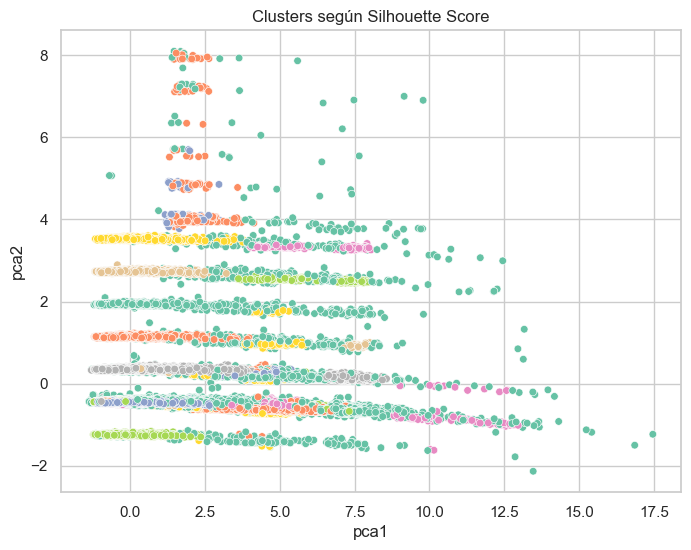

In [ ]:
# Silhouette
plt.figure()
sns.scatterplot(data=sample_df, x='pca1', y='pca2', hue='cluster_silhouette', palette='Set2', s=30, legend=False)
plt.title("Clusters según Silhouette Score")
plt.show()

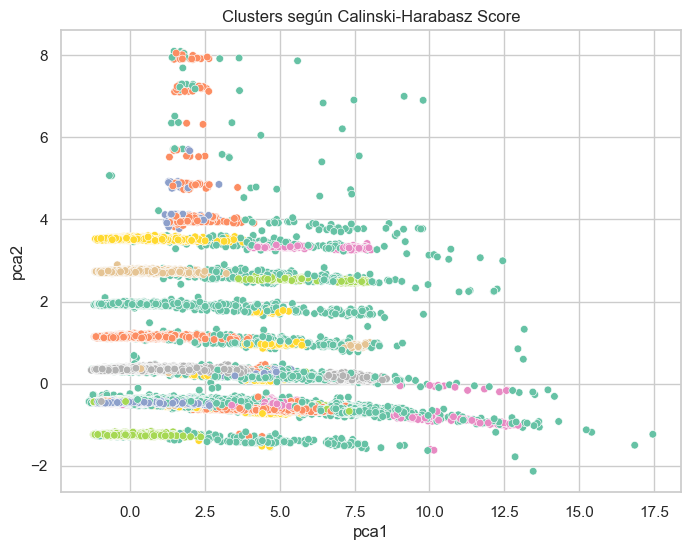

In [ ]:
# Calinski-Harabasz
plt.figure()
sns.scatterplot(data=sample_df, x='pca1', y='pca2', hue='cluster_calinski_harabasz', palette='Set2', s=30, legend=False)
plt.title("Clusters según Calinski-Harabasz Score")
plt.show()

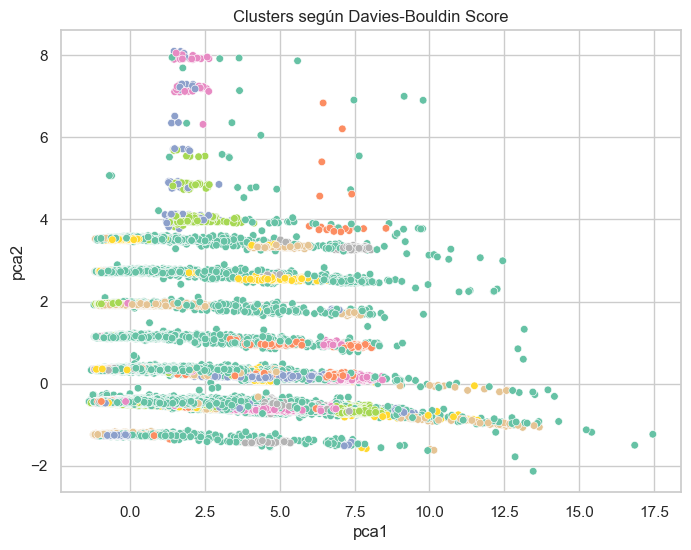

In [ ]:
# Davies-Bouldin
plt.figure()
sns.scatterplot(data=sample_df, x='pca1', y='pca2', hue='cluster_davies_bouldin', palette='Set2', s=30, legend=False)
plt.title("Clusters según Davies-Bouldin Score")
plt.show()

In [ ]:
# Mostrar tamaños por clúster
sample_df['cluster_silhouette'].value_counts(normalize=True).head(10)

cluster_silhouette
 41    0.470873
 38    0.093893
-1     0.059447
 30    0.040673
 37    0.027667
 40    0.025860
 36    0.017407
 24    0.017133
 32    0.011933
 29    0.011720
Name: proportion, dtype: float64

In [ ]:
# Mostrar tamaños por clúster
sample_df['cluster_calinski_harabasz'].value_counts(normalize=True).head(10)

cluster_calinski_harabasz
 41    0.470873
 38    0.093893
-1     0.059447
 30    0.040673
 37    0.027667
 40    0.025860
 36    0.017407
 24    0.017133
 32    0.011933
 29    0.011720
Name: proportion, dtype: float64

In [ ]:
# Mostrar tamaños por clúster
sample_df['cluster_davies_bouldin'].value_counts(normalize=True).head(10)

cluster_davies_bouldin
-1      0.457567
 63     0.025547
 103    0.024400
 92     0.014560
 98     0.013573
 61     0.011153
 231    0.010133
 230    0.008707
 35     0.007687
 89     0.007520
Name: proportion, dtype: float64

In [ ]:
cluster_counts_df

,Métrica,Cantidad de Clústeres
0,cluster_silhouette,85
1,cluster_calinski_harabasz,85
2,cluster_davies_bouldin,1082


## Agglomerative Hierarchical Clustering

### Silhouette

In [ ]:
# Definir la grilla de hiperparámetros
param_grid = {
    'n_clusters': range(2, 11),
    'linkage': [ 'single']

}

# Intentar cargar resultados parciales
try:
    resultados_parciales = pd.read_csv(resultados_path)
    print("✅ Resultados parciales cargados.")
    iteracion_inicial = len(resultados_parciales)
    mejor_score = resultados_parciales['silhouette'].max()
    mejor_idx = resultados_parciales['silhouette'].idxmax()
    mejor_modelo = pickle.load(open(modelo_path, 'rb'))
except:
    resultados_parciales = []
    iteracion_inicial = 0
    mejor_score = -1
    mejor_modelo = None

# Inicializar timer global
inicio_total = time.time()
total_iteraciones = len(list(ParameterGrid(param_grid)))

# Bucle principal con barra de progreso
with tqdm(total=total_iteraciones, initial=iteracion_inicial, desc="Entrenando Agglomerative") as pbar:
    for i, params in enumerate(ParameterGrid(param_grid)):
        if i < iteracion_inicial:
            continue  # Saltar ya entrenados

        print(f"▶ Iteración {i+1}/{total_iteraciones} - {params}")
        inicio = time.time()
        modelo = AgglomerativeClustering(**params)
        modelo.fit(X_sample)
        etiquetas = modelo.labels_
        tiempo = round(time.time() - inicio, 2)

        elapsed = time.time() - inicio
        tiempo_total = time.time() - inicio_total

        # Validación: al menos 2 clústeres válidos
        if len(set(etiquetas)) <= 1 or (etiquetas == -1).all():
            print("⚠️ Solo se encontró un clúster o todos son ruido. Se omite esta combinación.")
            sil, db, ch = np.nan, np.nan, np.nan
        else:
            try:
                sil = silhouette_score(X_sample, etiquetas)
            except:
                sil = np.nan

        # Guardar mejor modelo
        if sil > mejor_score:
            mejor_score = sil
            mejor_modelo = modelo
            pickle.dump(mejor_modelo, open("Agglomerative_model_final_sil.pkl", "wb"))
            print("✅ Nuevo mejor modelo guardado.")


        # Almacenar resultados parciales
        resultados_parciales.append({
            **params,
            "silhouette": sil,
            "tiempo_iter_s": round(elapsed, 2),
            "tiempo_s": tiempo
        })

        pd.DataFrame(resultados_parciales).to_csv("resultados_parciales_Agglomerative_sil.csv", index=False)

        print(f"⏱️ Tiempo de esta iteración: {formatear_tiempo(elapsed)}")
        print(f"⏱️ Tiempo total acumulado: {formatear_tiempo(time.time() - inicio_total)}")



pd.DataFrame(resultados_parciales)

Entrenando Agglomerative:   0%|                                                                  | 0/9 [00:00<?, ?it/s]

▶ Iteración 1/9 - {'linkage': 'single', 'n_clusters': 2}
✅ Nuevo mejor modelo guardado.
⏱️ Tiempo de esta iteración: 5m 1s
⏱️ Tiempo total acumulado: 10m 2s
▶ Iteración 2/9 - {'linkage': 'single', 'n_clusters': 3}
✅ Nuevo mejor modelo guardado.
⏱️ Tiempo de esta iteración: 5m 26s
⏱️ Tiempo total acumulado: 20m 36s
▶ Iteración 3/9 - {'linkage': 'single', 'n_clusters': 4}
⏱️ Tiempo de esta iteración: 5m 3s
⏱️ Tiempo total acumulado: 30m 46s
▶ Iteración 4/9 - {'linkage': 'single', 'n_clusters': 5}
⏱️ Tiempo de esta iteración: 5m 4s
⏱️ Tiempo total acumulado: 40m 54s
▶ Iteración 5/9 - {'linkage': 'single', 'n_clusters': 6}
⏱️ Tiempo de esta iteración: 5m 3s
⏱️ Tiempo total acumulado: 51m 3s
▶ Iteración 6/9 - {'linkage': 'single', 'n_clusters': 7}
⏱️ Tiempo de esta iteración: 5m 3s
⏱️ Tiempo total acumulado: 61m 12s
▶ Iteración 7/9 - {'linkage': 'single', 'n_clusters': 8}
⏱️ Tiempo de esta iteración: 5m 3s
⏱️ Tiempo total acumulado: 71m 20s
▶ Iteración 8/9 - {'linkage': 'single', 'n_cluster

Entrenando Agglomerative:   0%|                                                                | 0/9 [1:31:20<?, ?it/s]

⏱️ Tiempo de esta iteración: 5m 1s
⏱️ Tiempo total acumulado: 91m 20s


,linkage,n_clusters,silhouette,tiempo_iter_s,tiempo_s
0,single,2,0.847225,301.84,301.84
1,single,3,0.847259,326.36,326.36
2,single,4,0.838934,303.54,303.54
3,single,5,0.838927,304.04,304.04
4,single,6,0.838935,303.27,303.27
5,single,7,0.827464,303.98,303.98
6,single,8,0.812013,303.38,303.38
7,single,9,0.812230,301.96,301.96
8,single,10,0.812216,301.78,301.78


### Davies - Bouldin

In [ ]:
# Definir la grilla de hiperparámetros
param_grid = {
    'n_clusters': range(2, 11),
    # 'linkage': ['ward', 'complete', 'average', 'single']
    'linkage': ['single']
}

# Intentar cargar resultados parciales
try:
    resultados_parciales = pd.read_csv(resultados_path)
    print("✅ Resultados parciales cargados.")
    iteracion_inicial = len(resultados_parciales)
    mejor_score = resultados_parciales['davies_bouldin'].min()
    mejor_idx = resultados_parciales['davies_bouldin'].idxmin()
    mejor_modelo = pickle.load(open(modelo_path, 'rb'))
except:
    resultados_parciales = []
    iteracion_inicial = 0
    mejor_score = -1
    mejor_modelo = None

# Inicializar timer global
inicio_total = time.time()
total_iteraciones = len(list(ParameterGrid(param_grid)))

# Bucle principal con barra de progreso
with tqdm(total=total_iteraciones, initial=iteracion_inicial, desc="Entrenando Agglomerative") as pbar:
    for i, params in enumerate(ParameterGrid(param_grid)):
        if i < iteracion_inicial:
            continue  # Saltar ya entrenados

        print(f"▶ Iteración {i+1}/{total_iteraciones} - {params}")
        inicio = time.time()
        modelo = AgglomerativeClustering(**params)
        modelo.fit(X_sample)
        etiquetas = modelo.labels_
        tiempo = round(time.time() - inicio, 2)

        elapsed = time.time() - inicio
        tiempo_total = time.time() - inicio_total

        # Validación: al menos 2 clústeres válidos
        if len(set(etiquetas)) <= 1 or (etiquetas == -1).all():
            print("⚠️ Solo se encontró un clúster o todos son ruido. Se omite esta combinación.")
            # sil, db, ch = np.nan, np.nan, np.nan
            db = np.nan

        else:
            try:
                db = davies_bouldin_score(X_sample, etiquetas)
            except:
                db = np.nan

        # Guardar mejor modelo
        if db < mejor_score or mejor_score == -1:
        # if sil > mejor_score:
            mejor_score = db
            mejor_modelo = modelo
            pickle.dump(mejor_modelo, open("Agglomerative_model_final_db.pkl", "wb"))
            print("✅ Nuevo mejor modelo guardado.")


        # Almacenar resultados parciales
        resultados_parciales.append({
            **params,
            "davies_bouldin": db,
            "tiempo_iter_s": round(elapsed, 2),
            "tiempo_s": tiempo
        })

        pd.DataFrame(resultados_parciales).to_csv("resultados_parciales_Agglomerative_db.csv", index=False)


        print(f"⏱️ Tiempo de esta iteración: {formatear_tiempo(elapsed)}")
        print(f"⏱️ Tiempo total acumulado: {formatear_tiempo(time.time() - inicio_total)}")



pd.DataFrame(resultados_parciales)

Entrenando Agglomerative:   0%|                                                                  | 0/9 [00:00<?, ?it/s]

▶ Iteración 1/9 - {'linkage': 'single', 'n_clusters': 2}
✅ Nuevo mejor modelo guardado.
⏱️ Tiempo de esta iteración: 5m 4s
⏱️ Tiempo total acumulado: 5m 4s
▶ Iteración 2/9 - {'linkage': 'single', 'n_clusters': 3}
⏱️ Tiempo de esta iteración: 5m 6s
⏱️ Tiempo total acumulado: 10m 10s
▶ Iteración 3/9 - {'linkage': 'single', 'n_clusters': 4}
⏱️ Tiempo de esta iteración: 5m 4s
⏱️ Tiempo total acumulado: 15m 15s
▶ Iteración 4/9 - {'linkage': 'single', 'n_clusters': 5}
✅ Nuevo mejor modelo guardado.
⏱️ Tiempo de esta iteración: 5m 4s
⏱️ Tiempo total acumulado: 20m 20s
▶ Iteración 5/9 - {'linkage': 'single', 'n_clusters': 6}
✅ Nuevo mejor modelo guardado.
⏱️ Tiempo de esta iteración: 5m 5s
⏱️ Tiempo total acumulado: 25m 26s
▶ Iteración 6/9 - {'linkage': 'single', 'n_clusters': 7}
⏱️ Tiempo de esta iteración: 5m 5s
⏱️ Tiempo total acumulado: 30m 31s
▶ Iteración 7/9 - {'linkage': 'single', 'n_clusters': 8}
⏱️ Tiempo de esta iteración: 5m 5s
⏱️ Tiempo total acumulado: 35m 37s
▶ Iteración 8/9 - {'

Entrenando Agglomerative:   0%|                                                                  | 0/9 [45:50<?, ?it/s]

⏱️ Tiempo de esta iteración: 5m 7s
⏱️ Tiempo total acumulado: 45m 50s


,linkage,n_clusters,davies_bouldin,tiempo_iter_s,tiempo_s
0,single,2,0.102661,304.32,304.32
1,single,3,0.156864,306.42,306.42
2,single,4,0.186229,304.80,304.80
3,single,5,0.088210,304.90,304.90
4,single,6,0.087570,305.51,305.51
5,single,7,0.169029,305.45,305.45
6,single,8,0.098262,305.75,305.75
7,single,9,0.169627,305.71,305.71
8,single,10,0.183479,307.27,307.27


### Calinski - Harabasz

In [ ]:
# Definir la grilla de hiperparámetros
param_grid = {
    'n_clusters': range(2, 11),
    # 'linkage': ['ward', 'complete', 'average', 'single']
    'linkage': [ 'single']

}

# Intentar cargar resultados parciales
try:
    resultados_parciales = pd.read_csv(resultados_path)
    print("✅ Resultados parciales cargados.")
    iteracion_inicial = len(resultados_parciales)
    mejor_score = resultados_parciales['calinski_harabasz'].max()
    mejor_idx = resultados_parciales['calinski_harabasz'].idxmax()
    mejor_modelo = pickle.load(open(modelo_path, 'rb'))
except:
    resultados_parciales = []
    iteracion_inicial = 0
    mejor_score = -1
    mejor_modelo = None

# Inicializar timer global
inicio_total = time.time()
total_iteraciones = len(list(ParameterGrid(param_grid)))

# Bucle principal con barra de progreso
with tqdm(total=total_iteraciones, initial=iteracion_inicial, desc="Entrenando Agglomerative calinski_harabasz") as pbar:
    for i, params in enumerate(ParameterGrid(param_grid)):
        if i < iteracion_inicial:
            continue  # Saltar ya entrenados

        print(f"▶ Iteración {i+1}/{total_iteraciones} - {params}")
        inicio = time.time()
        modelo = AgglomerativeClustering(**params)
        modelo.fit(X_sample)
        etiquetas = modelo.labels_
        tiempo = round(time.time() - inicio, 2)

        elapsed = time.time() - inicio
        tiempo_total = time.time() - inicio_total

        # Validación: al menos 2 clústeres válidos
        if len(set(etiquetas)) <= 1 or (etiquetas == -1).all():
            print("⚠️ Solo se encontró un clúster o todos son ruido. Se omite esta combinación.")
            sil, db, ch = np.nan, np.nan, np.nan
        else:
            try:
                ch = calinski_harabasz_score(X_sample, etiquetas)
            except:
                sil = np.nan

        # Guardar mejor modelo
        if ch > mejor_score:
            mejor_score = ch
            mejor_modelo = modelo
            pickle.dump(mejor_modelo, open("Agglomerative_model_final_ch.pkl", "wb"))
            print("✅ Nuevo mejor modelo guardado.")


        # Almacenar resultados parciales
        resultados_parciales.append({
            **params,
            "calinski_harabasz": ch,
            "tiempo_iter_s": round(elapsed, 2),
            "tiempo_s": tiempo
        })

        pd.DataFrame(resultados_parciales).to_csv("resultados_parciales_Agglomerative_ch.csv", index=False)


        print(f"⏱️ Tiempo de esta iteración: {formatear_tiempo(elapsed)}")
        print(f"⏱️ Tiempo total acumulado: {formatear_tiempo(time.time() - inicio_total)}")



pd.DataFrame(resultados_parciales)

Entrenando Agglomerative calinski_harabasz:   0%|                                                | 0/9 [00:00<?, ?it/s]

▶ Iteración 1/9 - {'linkage': 'single', 'n_clusters': 2}
✅ Nuevo mejor modelo guardado.
⏱️ Tiempo de esta iteración: 8m 29s
⏱️ Tiempo total acumulado: 8m 29s
▶ Iteración 2/9 - {'linkage': 'single', 'n_clusters': 3}
✅ Nuevo mejor modelo guardado.
⏱️ Tiempo de esta iteración: 8m 25s
⏱️ Tiempo total acumulado: 16m 55s
▶ Iteración 3/9 - {'linkage': 'single', 'n_clusters': 4}
⏱️ Tiempo de esta iteración: 8m 24s
⏱️ Tiempo total acumulado: 25m 20s
▶ Iteración 4/9 - {'linkage': 'single', 'n_clusters': 5}
⏱️ Tiempo de esta iteración: 8m 36s
⏱️ Tiempo total acumulado: 33m 56s
▶ Iteración 5/9 - {'linkage': 'single', 'n_clusters': 6}
⏱️ Tiempo de esta iteración: 8m 29s
⏱️ Tiempo total acumulado: 42m 26s
▶ Iteración 6/9 - {'linkage': 'single', 'n_clusters': 7}
⏱️ Tiempo de esta iteración: 8m 17s
⏱️ Tiempo total acumulado: 50m 43s
▶ Iteración 7/9 - {'linkage': 'single', 'n_clusters': 8}
⏱️ Tiempo de esta iteración: 8m 21s
⏱️ Tiempo total acumulado: 59m 5s
▶ Iteración 8/9 - {'linkage': 'single', 'n_c

Entrenando Agglomerative calinski_harabasz:   0%|                                              | 0/9 [1:15:46<?, ?it/s]

⏱️ Tiempo de esta iteración: 8m 14s
⏱️ Tiempo total acumulado: 75m 46s


,linkage,n_clusters,calinski_harabasz,tiempo_iter_s,tiempo_s
0,single,2,46.304692,509.67,509.67
1,single,3,159.655796,505.81,505.81
2,single,4,120.231925,504.53,504.53
3,single,5,90.882337,516.03,516.03
4,single,6,86.459954,509.56,509.56
5,single,7,83.647554,497.42,497.42
6,single,8,71.954042,501.82,501.82
7,single,9,332.881135,506.23,506.23
8,single,10,301.027937,494.28,494.28


In [ ]:
#Eliminar columnas duplicadas antes de unir (como tiempo_s o iter_s)
sil_df = sil_df.drop(columns=['tiempo_iter_s', 'tiempo_s'], errors='ignore')
ch_df = ch_df.drop(columns=['tiempo_iter_s', 'tiempo_s'], errors='ignore')
db_df = db_df.drop(columns=['tiempo_iter_s', 'tiempo_s'], errors='ignore')

df_final = sil_df.merge(ch_df, on=['linkage', 'n_clusters'], how='inner')
df_final = df_final.merge(db_df, on=['linkage', 'n_clusters'], how='inner')

print("✅ Tabla combinada guardada correctamente")
df_final

✅ Tabla combinada guardada correctamente


,linkage,n_clusters,silhouette,calinski_harabasz,davies_bouldin
0,single,2,0.847225,46.304692,0.102661
1,single,3,0.847259,159.655796,0.156864
2,single,4,0.838934,120.231925,0.186229
3,single,5,0.838927,90.882337,0.088210
4,single,6,0.838935,86.459954,0.087570
5,single,7,0.827464,83.647554,0.169029
6,single,8,0.812013,71.954042,0.098262
7,single,9,0.812230,332.881135,0.169627
8,single,10,0.812216,301.027937,0.183479


### Visualización Clusters Agglomerative Hierarchical Clustering

In [ ]:
# Diccionario para guardar etiquetas por métrica
labels_dict = {}

# Reentrenar con los mismos parámetros y asignar clústeres
for key, path in model_paths.items():
    with open(path, "rb") as f:
        old_model = pickle.load(f)
        params = old_model.get_params()
        new_model = AgglomerativeClustering(**params)
        labels = new_model.fit_predict(X_sample)
        labels_dict[f'cluster_{key}'] = labels

# Construir DataFrame con etiquetas
df_clusters_agglomerative = pd.DataFrame(labels_dict)
df_clusters_agglomerative

C:\Users\kcarrascal\AppData\Local\anaconda3\envs\sklearn_env\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator AgglomerativeClustering from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,cluster_silhouette,cluster_calinski_harabasz,cluster_davies_bouldin
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
...,...,...,...
149995,0,0,0
149996,0,0,0
149997,0,0,0
149998,0,0,0


In [ ]:
df_clusters_agglomerative['cluster_silhouette'].value_counts(normalize=True)

cluster_silhouette
0    0.999980
2    0.000013
1    0.000007
Name: proportion, dtype: float64

In [ ]:
df_clusters_agglomerative['cluster_calinski_harabasz'].value_counts(normalize=True)

cluster_calinski_harabasz
0    0.999767
1    0.000187
5    0.000007
6    0.000007
7    0.000007
2    0.000007
8    0.000007
4    0.000007
3    0.000007
Name: proportion, dtype: float64

In [ ]:
df_clusters_agglomerative['cluster_davies_bouldin'].value_counts(normalize=True)

cluster_davies_bouldin
0    0.999967
5    0.000007
3    0.000007
2    0.000007
4    0.000007
1    0.000007
Name: proportion, dtype: float64

In [ ]:
# Aplicar PCA a X_sample
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

# Convertir a DataFrame para graficar
pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
pca_df = pd.concat([pca_df, df_clusters_agglomerative], axis=1)
pca_df.head()

,PCA1,PCA2,cluster_silhouette,cluster_calinski_harabasz,cluster_davies_bouldin
0,-0.478403,-0.478001,0,0,0
1,-0.334576,-0.440547,0,0,0
2,-1.029225,0.351894,0,0,0
3,-0.810399,-0.467652,0,0,0
4,-0.689826,3.499005,0,0,0


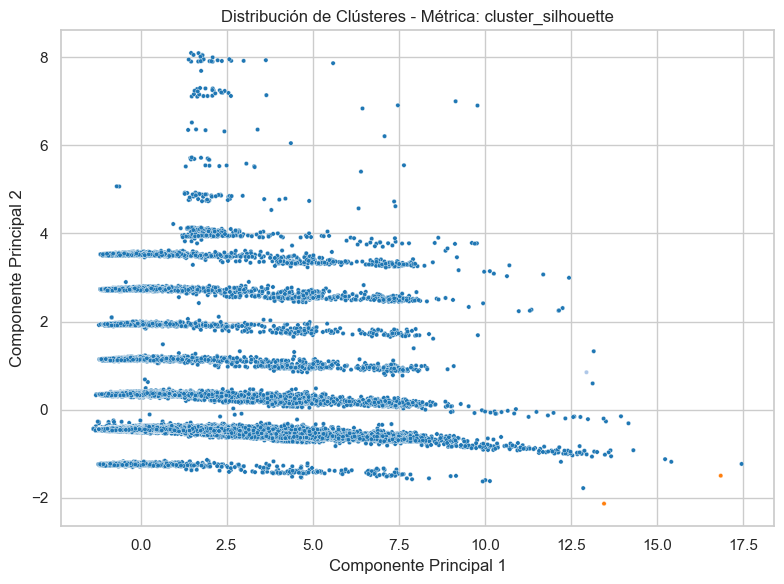

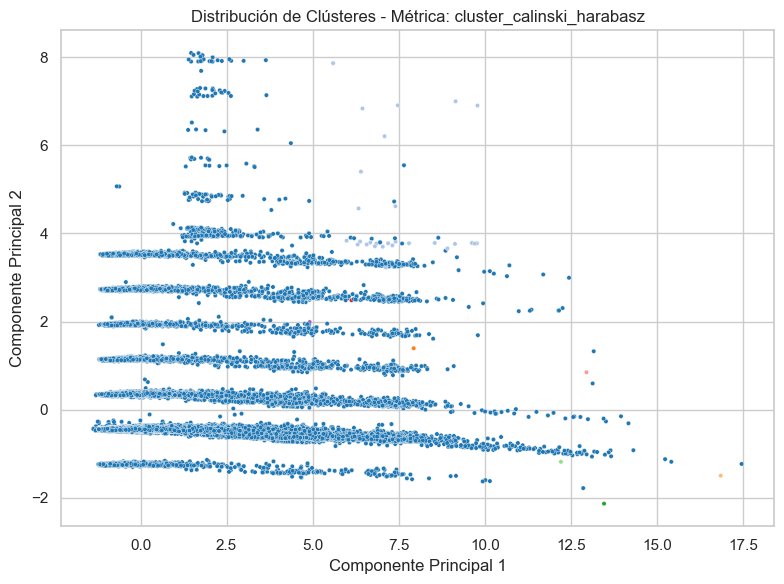

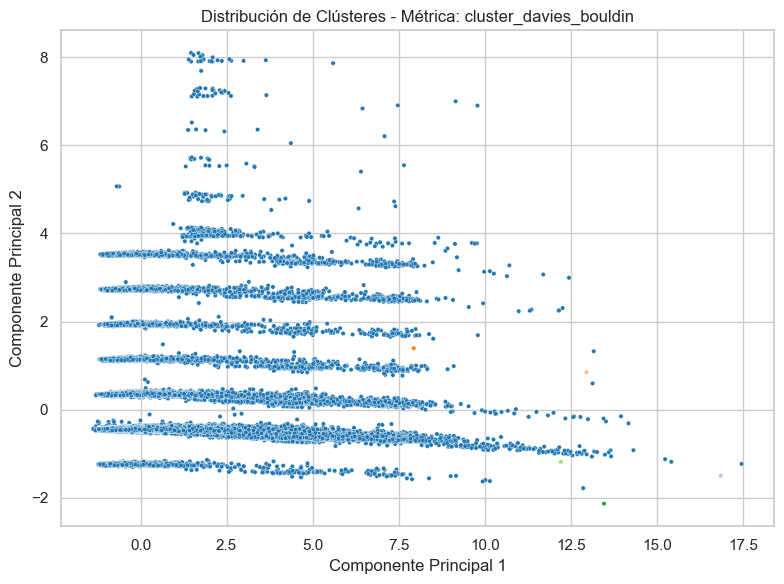

In [ ]:
# Configurar el estilo
sns.set(style="whitegrid", palette="tab10")

# Iterar sobre cada métrica y graficar
for metric in df_clusters_agglomerative.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue=metric, palette='tab20', s=10, legend=False)
    plt.title(f"Distribución de Clústeres - Métrica: {metric}")
    plt.xlabel("Componente Principal 1")
    plt.ylabel("Componente Principal 2")
    plt.tight_layout()
    plt.show()


## K-Medoids

### Silhouette

In [ ]:
# Definir la grilla de hiperparámetros
param_grid = {
    'n_clusters': range(2, 11),
    'init': ['heuristic', 'random'],
    'method': ['alternate'],
    'metric': ['euclidean', 'manhattan']
}

# Intentar cargar resultados parciales
try:
    resultados_parciales = pd.read_csv(resultados_path)
    print("✅ Resultados parciales cargados.")
    iteracion_inicial = len(resultados_parciales)
    mejor_score = resultados_parciales['silhouette'].max()
    mejor_idx = resultados_parciales['silhouette'].idxmax()
    mejor_modelo = pickle.load(open(modelo_path, 'rb'))
except:
    resultados_parciales = []
    iteracion_inicial = 0
    mejor_score = -1
    mejor_modelo = None

# Inicializar timer global
inicio_total = time.time()
total_iteraciones = len(list(ParameterGrid(param_grid)))

# Bucle principal con barra de progreso
with tqdm(total=total_iteraciones, initial=iteracion_inicial, desc="Entrenando K-Medoids") as pbar:
    for i, params in enumerate(ParameterGrid(param_grid)):
        if i < iteracion_inicial:
            continue  # Saltar ya entrenados

        print(f"▶ Iteración {i+1}/{total_iteraciones} - {params}")
        inicio = time.time()
        modelo = KMedoids(**params, random_state=42)
        modelo.fit(X_sample)
        etiquetas = modelo.labels_
        tiempo = round(time.time() - inicio, 2)

        elapsed = time.time() - inicio
        tiempo_total = time.time() - inicio_total

        # Validación: al menos 2 clústeres válidos
        if len(set(etiquetas)) <= 1 or (etiquetas == -1).all():
            print("⚠️ Solo se encontró un clúster o todos son ruido. Se omite esta combinación.")
            sil, db, ch = np.nan, np.nan, np.nan
        else:
            try:
                sil = silhouette_score(X_sample, etiquetas)
#                 db = davies_bouldin_score(X_sample, etiquetas)
#                 ch = calinski_harabasz_score(X_sample, etiquetas)
            except:
#                 sil, db, ch = np.nan, np.nan, np.nan
                sil = np.nan

        # Guardar mejor modelo
        if sil > mejor_score:
            mejor_score = sil
            mejor_modelo = modelo
            pickle.dump(mejor_modelo, open("KMedoids_model_final_sil.pkl", "wb"))
            print("✅ Nuevo mejor modelo guardado.")


        # Almacenar resultados parciales
        resultados_parciales.append({
            **params,
            "silhouette": sil,
#             "davies_bouldin": db,
#             "calinski_harabasz": ch,
            "tiempo_iter_s": round(elapsed, 2),
            "tiempo_s": tiempo
        })

        pd.DataFrame(resultados_parciales).to_csv("resultados_parciales_KMedoids_sil.csv", index=False)


        print(f"⏱️ Tiempo de esta iteración: {formatear_tiempo(elapsed)}")
        print(f"⏱️ Tiempo total acumulado: {formatear_tiempo(time.time() - inicio_total)}")



pd.DataFrame(resultados_parciales)

Entrenando K-Medoids:   0%|                                                                     | 0/36 [00:00<?, ?it/s]


▶ Iteración 1/36 - {'init': 'heuristic', 'method': 'alternate', 'metric': 'euclidean', 'n_clusters': 2}


MemoryError: Unable to allocate 168. GiB for an array with shape (150000, 150000) and data type float64

# Modelos de Deep Learning

## Deep Clustering (DCN)

In [ ]:
# 1. Data
X = np.asarray(X)
input_dim = X.shape[1]

# 2. Función para construir DCN
def build_dcn(input_dim, encoding_dim, n_clusters, learning_rate, loss_weight):
    inp = Input(shape=(input_dim,), name='input')
    x = Dense(256, activation='relu')(inp)
    x = Dense(128, activation='relu')(x)
    encoded = Dense(encoding_dim, activation='relu', name='encoder_output')(x)
    x = Dense(128, activation='relu')(encoded)
    x = Dense(256, activation='relu')(x)
    decoded = Dense(input_dim, activation='linear', name='reconstruction')(x)
    q = Dense(n_clusters, activation='softmax', name='cluster')(encoded)
    model = Model(inputs=inp, outputs=[decoded, q])
    model.compile(
        optimizer=Adam(learning_rate),
        loss={'reconstruction':'mse', 'cluster':'kld'},
        loss_weights={'reconstruction':1.0, 'cluster':loss_weight}
    )
    encoder = Model(inputs=inp, outputs=encoded)
    return model, encoder

# 3. Target distribution function
def target_distribution(q):
    weight = q**2 / q.sum(axis=0)
    return (weight.T / weight.sum(axis=1)).T

# 4. Definir grilla centrada en los 4 hiperparámetros clave
param_grid = {
    'encoding_dim': [16, 32],
    'loss_weight': [0.1, 0.5],
    'learning_rate': [1e-3, 1e-4],
    'batch_size': [256, 512],
    'ae_epochs': [50],        # fijo
    'dcn_epochs': [30],       # fijo
    'n_clusters': [5]         # fijo
}

combinations = list(ParameterGrid(param_grid))

# 5. Búsqueda
results = []
for params in tqdm(combinations, desc="Grid Search DCN"):
    start = time.time()
    # 5.1 Construir y preentrenar autoencoder
    dcn, encoder = build_dcn(
        input_dim, params['encoding_dim'],
        params['n_clusters'], params['learning_rate'],
        params['loss_weight']
    )
    # pretraining
    ae = Model(dcn.input, dcn.get_layer('reconstruction').output)
    ae.compile(optimizer=Adam(params['learning_rate']), loss='mse')
    ae.fit(X, X,
           epochs=params['ae_epochs'],
           batch_size=params['batch_size'],
           verbose=0)
    # 5.2 Inicializar cluster centers
    emb = encoder.predict(X)
    kmeans = KMeans(n_clusters=params['n_clusters'], n_init=10, random_state=42)
    labels_init = kmeans.fit_predict(emb)
    # set cluster layer weights
    cluster_layer = dcn.get_layer('cluster')
    cluster_layer.set_weights([kmeans.cluster_centers_.T, np.zeros(params['n_clusters'])])
    # 5.3 Entrenamiento DEC
    q = dcn.predict(X)[1]
    p = target_distribution(q)
    for epoch in range(params['dcn_epochs']):
        dcn.fit(
            X, {'reconstruction': X, 'cluster': p},
            batch_size=params['batch_size'], epochs=1, verbose=0
        )
        if epoch % 10 == 0:
            q = dcn.predict(X)[1]
            p = target_distribution(q)
    # 5.4 Evaluación (con manejo de errores)
    try:
        sil = silhouette_score(X, labels_init)
        db  = davies_bouldin_score(X, labels_init)
        ch  = calinski_harabasz_score(X, labels_init)
    except ValueError:
        # Sólo hay 1 cluster; no se puede calcular la métrica
        sil, db, ch = np.nan, np.nan, np.nan

    elapsed = time.time() - start

    results.append({
        **params,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch,
        'time_s': round(elapsed, 2),
        'model': dcn
    })

# 6. Consolidación
df = pd.DataFrame(results)
df.drop(columns='model').to_csv('deep_clustering_grid_results.csv', index=False)

# 7. Selección de mejores modelos
best_sil = df.loc[df['silhouette'].idxmax()]
best_db  = df.loc[df['davies_bouldin'].idxmin()]
best_ch  = df.loc[df['calinski_harabasz'].idxmax()]

# 8. Guardar modelos
best_sil['model'].save('dcn_best_silhouette.h5')
best_db ['model'].save('dcn_best_davies_bouldin.h5')
best_ch ['model'].save('dcn_best_calinski_harabasz.h5')

print("Mejores configuraciones:")
print("Silhouette:", best_sil.to_dict())
print("Davies–Bouldin:", best_db.to_dict())
print("Calinski–Harabasz:", best_ch.to_dict())



Grid Search DCN:   0%|          | 0/16 [00:00<?, ?it/s]

4688/4688 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step



Grid Search DCN:   6%|▋         | 1/16 [12:47<3:11:53, 767.59s/it]

4688/4688 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step



Grid Search DCN:  12%|█▎        | 2/16 [25:20<2:57:07, 759.09s/it]

...

4688/4688 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step



Grid Search DCN:  94%|█████████▍| 15/16 [2:58:38<11:33, 693.49s/it]

4688/4688 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


Grid Search DCN: 100%|██████████| 16/16 [3:10:16<00:00, 713.56s/it]


Mejores configuraciones:
Silhouette: {'ae_epochs': 50, 'batch_size': 512, 'dcn_epochs': 30, 'encoding_dim': 32, 'learning_rate': 0.001, 'loss_weight': 0.5, 'n_clusters': 5, 'silhouette': 0.5902072976360091, 'davies_bouldin': 0.6784898004632246, 'calinski_harabasz': 107496.38865002993, 'time_s': 729.36, 'model': <Functional name=functional_45, built=True>}
Davies–Bouldin: {'ae_epochs': 50, 'batch_size': 256, 'dcn_epochs': 30, 'encoding_dim': 32, 'learning_rate': 0.001, 'loss_weight': 0.1, 'n_clusters': 5, 'silhouette': 0.5901062067237657, 'davies_bouldin': 0.6783717220777754, 'calinski_harabasz': 106355.90629336008, 'time_s': 788.19, 'model': <Functional name=functional_18, built=True>}
Calinski–Harabasz: {'ae_epochs': 50, 'batch_size': 512, 'dcn_epochs': 30, 'encoding_dim': 32, 'learning_rate': 0.001, 'loss_weight': 0.5, 'n_clusters': 5, 'silhouette': 0.5902072976360091, 'davies_bouldin': 0.6784898004632246, 'calinski_harabasz': 107496.38865002993, 'time_s': 729.36, 'model': <Functiona

In [ ]:
# Cargar resultados
df = pd.read_csv('deep_clustering_grid_results.csv')

# Selección de mejores combinaciones
mejor_silhouette = df.loc[df['silhouette'].idxmax()]
mejor_davies     = df.loc[df['davies_bouldin'].idxmin()]
mejor_calinski   = df.loc[df['calinski_harabasz'].idxmax()]


In [ ]:
# Cargar modelos
encoder_silhouette = load_model('dcn_best_silhouette.h5', compile=False)
encoder_davies     = load_model('dcn_best_davies_bouldin.h5', compile=False)
encoder_calinski   = load_model('dcn_best_calinski_harabasz.h5', compile=False)

# Obtener embeddings
X_emb_sil = encoder_silhouette.predict(X)
X_emb_dav = encoder_davies.predict(X)
X_emb_cal = encoder_calinski.predict(X)


4688/4688 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


In [ ]:
# Silhouette
X_emb_sil = encoder_silhouette.predict(X_sample)[1]
kmeans_sil = KMeans(n_clusters=int(mejor_silhouette["n_clusters"]), random_state=42)
labels_sil = kmeans_sil.fit_predict(X_emb_sil)

# Davies–Bouldin
X_emb_davies = encoder_davies.predict(X_sample)[1]
kmeans_davies = KMeans(n_clusters=int(mejor_davies["n_clusters"]), random_state=42)
labels_davies = kmeans_davies.fit_predict(X_emb_davies)

# Calinski–Harabasz
X_emb_calinski = encoder_calinski.predict(X_sample)[1]
kmeans_calinski = KMeans(n_clusters=int(mejor_calinski["n_clusters"]), random_state=42)
labels_calinski = kmeans_calinski.fit_predict(X_emb_calinski)


4688/4688 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step


### Visualización Clusters Deep Clustering (DCN)

In [ ]:
# DataFrame base
df_sample = pd.DataFrame(X)
df_sample["cluster_silhouette"] = labels_sil
df_sample["cluster_davies_bouldin"] = labels_davies
df_sample["cluster_calinski_harabasz"] = labels_calinski

# PCA para visualización
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)
df_sample["pca1"] = pca_result[:, 0]
df_sample["pca2"] = pca_result[:, 1]

def plot_clusters(df, col_cluster, title):
    plt.figure(figsize=(10, 6))

    # Tamaños
    cluster_counts = df[col_cluster].value_counts().to_dict()
    df['cluster_size'] = df[col_cluster].map(cluster_counts)
    df['marker_size'] = df['cluster_size'] / df['cluster_size'].max() * 100

    scatter = sns.scatterplot(
        x='pca1',
        y='pca2',
        hue=col_cluster,
        size='marker_size',
        sizes=(30, 300),
        data=df,
        alpha=0.7,
        edgecolor='white',
        palette='tab10',
        legend='brief'
    )

    # Eliminar leyenda de tamaños
    handles, labels = scatter.get_legend_handles_labels()
    new_handles, new_labels = [], []
    for h, l in zip(handles, labels):
        if "marker_size" in l:
            break
        new_handles.append(h)
        new_labels.append(l)

    plt.title(title)
    plt.legend(new_handles, new_labels, loc='best')
    plt.tight_layout()
    plt.show()


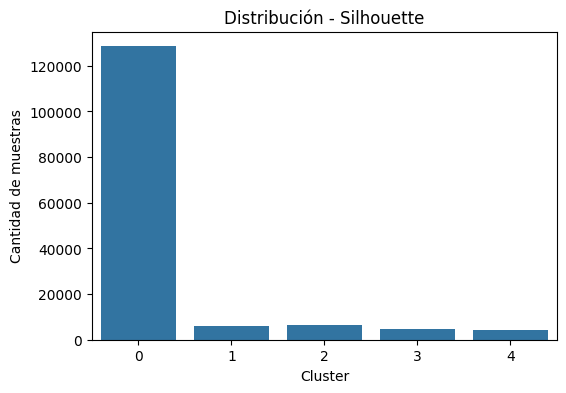

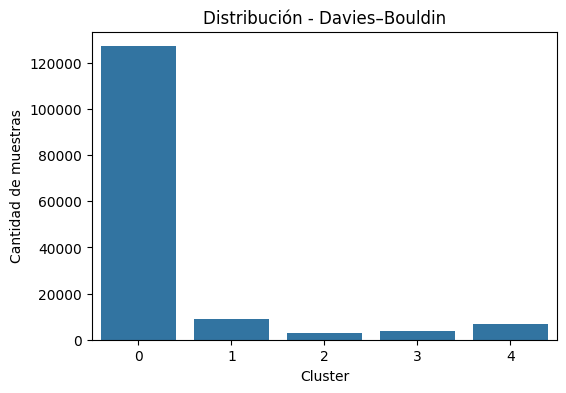

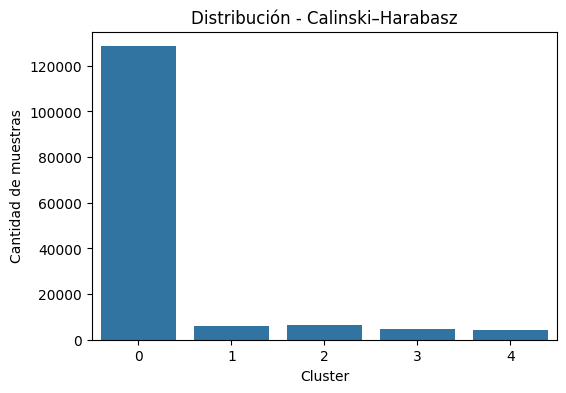

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cluster_distribution(labels, title):
    plt.figure(figsize=(6, 4))
    sns.countplot(x=labels)
    plt.title(title)
    plt.xlabel("Cluster")
    plt.ylabel("Cantidad de muestras")
    plt.show()

# Visualizar resultados
plot_cluster_distribution(labels_sil, "Distribución - Silhouette")
plot_cluster_distribution(labels_davies, "Distribución - Davies–Bouldin")
plot_cluster_distribution(labels_calinski, "Distribución - Calinski–Harabasz")


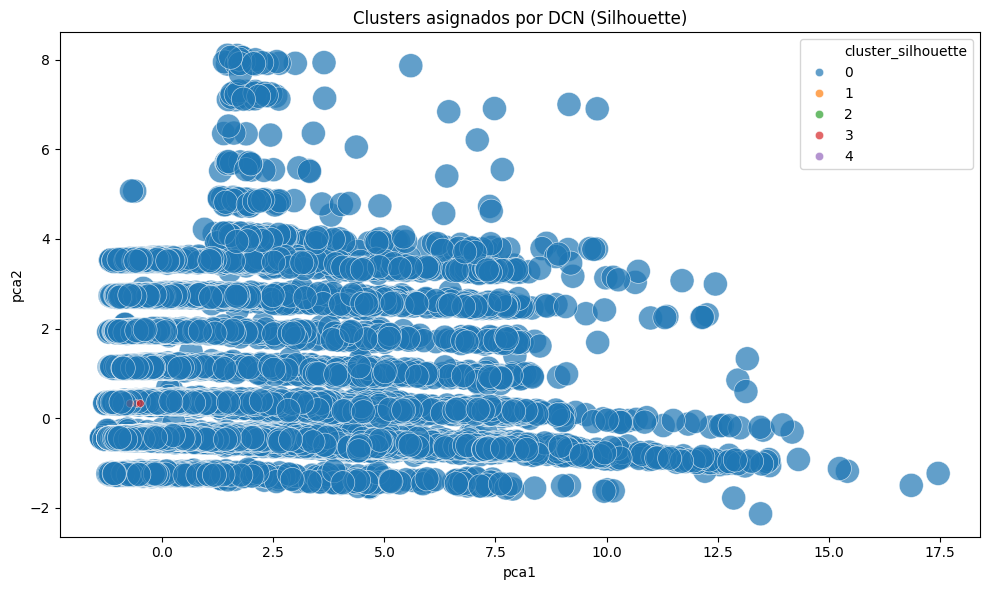

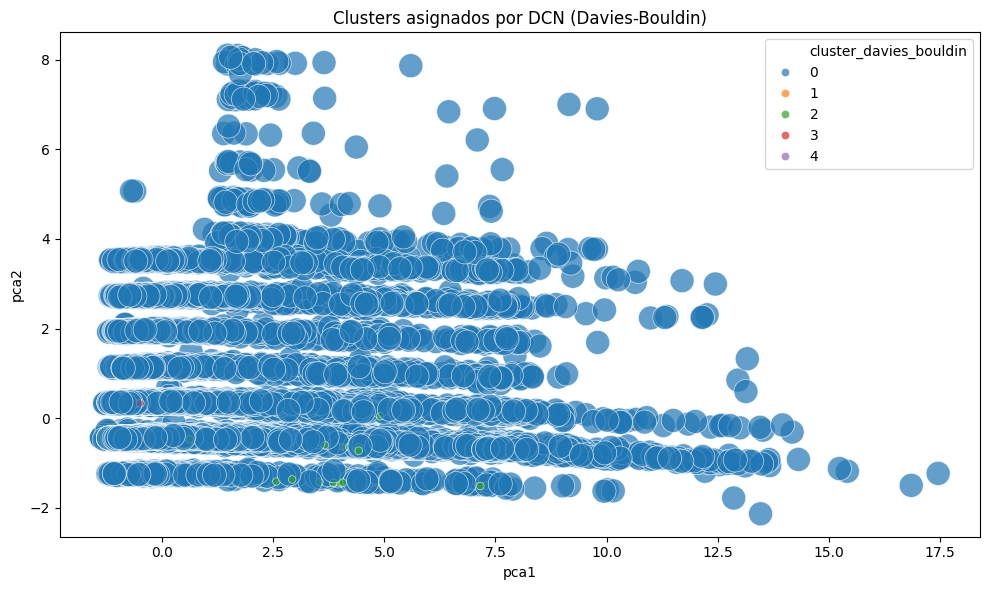

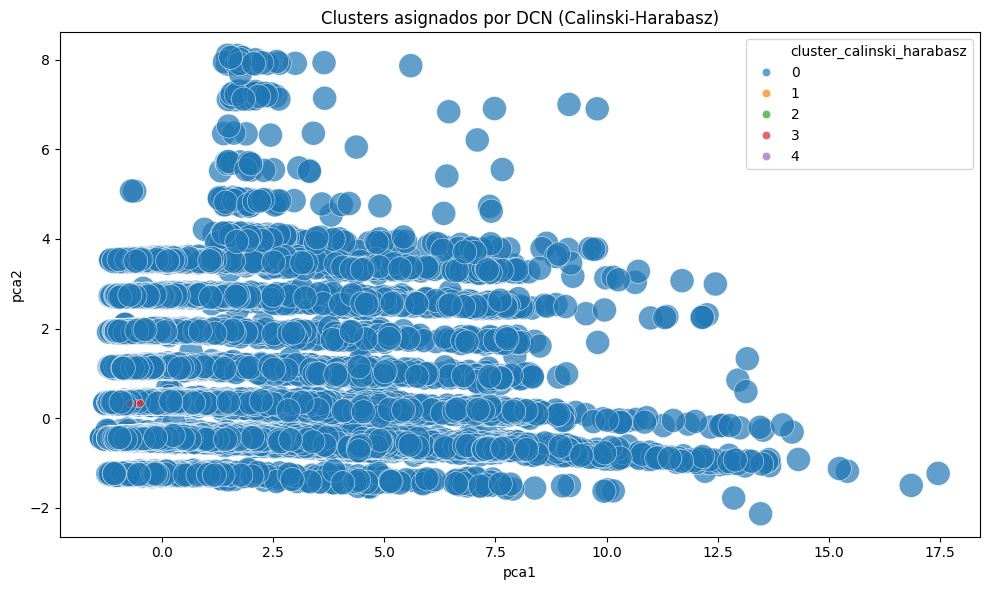

In [ ]:
plot_clusters(df_sample, 'cluster_silhouette', "Clusters asignados por DCN (Silhouette)")
plot_clusters(df_sample, 'cluster_davies_bouldin', "Clusters asignados por DCN (Davies-Bouldin)")
plot_clusters(df_sample, 'cluster_calinski_harabasz', "Clusters asignados por DCN (Calinski-Harabasz)")


## Deep Embedding Clustering (DEC)

In [ ]:
# Cargar X_sample
input_dim = X_sample.shape[1]

# ===========================
# Función para crear modelo
# ===========================
def build_autoencoder(input_dim, embedding_dim):
    input_layer = Input(shape=(input_dim,))
    x = Dense(128, activation='relu')(input_layer)
    x = Dense(64, activation='relu')(x)
    embedding = Dense(embedding_dim, activation='relu', name='embedding')(x)

    x = Dense(64, activation='relu')(embedding)
    x = Dense(128, activation='relu')(x)
    output = Dense(input_dim, activation='linear')(x)

    autoencoder = Model(input_layer, output)
    encoder = Model(input_layer, embedding)
    autoencoder.compile(optimizer=Adam(), loss='mse')
    return autoencoder, encoder

# ===========================
# Definir grilla
# ===========================
param_grid = {
    "n_clusters": [5, 6, 8],
    "embedding_dim": [10, 20],
    "pretrain_epochs": [30, 50]
}
combinaciones = list(product(param_grid["n_clusters"], param_grid["embedding_dim"], param_grid["pretrain_epochs"]))

resultados = []

# ===========================
# Loop de entrenamiento y evaluación
# ===========================
for i, (n_clusters, embedding_dim, epochs) in enumerate(tqdm(combinaciones, desc="Buscando mejor modelo DEC")):
    print(f"\n▶ Iteración {i+1}/{len(combinaciones)} - Clusters={n_clusters}, Embedding={embedding_dim}, Epochs={epochs}")
    inicio = time.time()

    # Construir modelo
    autoencoder, encoder = build_autoencoder(input_dim, embedding_dim)

    # Entrenar autoencoder
    autoencoder.fit(X_sample, X_sample, epochs=epochs, batch_size=256, shuffle=True, validation_split=0.2, verbose=0)

    # Obtener embeddings
    embeddings = encoder.predict(X_sample)

    # Clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    etiquetas = kmeans.fit_predict(embeddings)

    # Evaluación
    try:
        sil = silhouette_score(embeddings, etiquetas)
        db = davies_bouldin_score(embeddings, etiquetas)
        ch = calinski_harabasz_score(embeddings, etiquetas)
    except:
        sil, db, ch = np.nan, np.nan, np.nan

    elapsed = round(time.time() - inicio, 2)

    # Guardar modelo
    model_name = f"dec_k{n_clusters}_emb{embedding_dim}_ep{epochs}"
    autoencoder.save(f"{model_name}_autoencoder.h5")
    encoder.save(f"{model_name}_encoder.h5")

    # Guardar resultados
    resultados.append({
        "n_clusters": n_clusters,
        "embedding_dim": embedding_dim,
        "pretrain_epochs": epochs,
        "silhouette": sil,
        "davies_bouldin": db,
        "calinski_harabasz": ch,
        "tiempo_s": elapsed
    })

    # Guardado parcial en caso de interrupción
    pd.DataFrame(resultados).to_csv("resultados_grid_DEC.csv", index=False)

# Mostrar tabla final
df_resultados = pd.DataFrame(resultados)
df_resultados

Buscando mejor modelo DEC:   0%|                                                                | 0/12 [00:00<?, ?it/s]


▶ Iteración 1/12 - Clusters=5, Embedding=10, Epochs=30
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step


Buscando mejor modelo DEC:   8%|████▍                                                | 1/12 [12:36<2:18:36, 756.05s/it]


▶ Iteración 2/12 - Clusters=5, Embedding=10, Epochs=50
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step


Buscando mejor modelo DEC:  17%|████████▊                                            | 2/12 [25:37<2:08:32, 771.22s/it]

...


▶ Iteración 11/12 - Clusters=8, Embedding=20, Epochs=30
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step


Buscando mejor modelo DEC:  92%|███████████████████████████████████████████████▋    | 11/12 [2:21:57<12:43, 763.45s/it]


▶ Iteración 12/12 - Clusters=8, Embedding=20, Epochs=50
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step


Buscando mejor modelo DEC: 100%|████████████████████████████████████████████████████| 12/12 [2:34:55<00:00, 774.59s/it]


,n_clusters,embedding_dim,pretrain_epochs,silhouette,davies_bouldin,calinski_harabasz,tiempo_s
0,5,10,30,0.567796,0.739243,150499.703125,755.95
1,5,10,50,0.412293,0.830088,121364.523438,781.75
2,5,20,30,0.487276,0.730394,110319.460938,759.07
3,5,20,50,0.564310,0.769590,111616.703125,824.12
4,6,10,30,0.483696,0.887546,133387.531250,773.05
5,6,10,50,0.502141,0.778423,156733.734375,804.02
6,6,20,30,0.519925,0.778003,115384.242188,758.02
7,6,20,50,0.475878,0.864508,107902.515625,805.65
8,8,10,30,0.534043,0.827977,131844.968750,728.56
9,8,10,50,0.356904,0.978793,96493.187500,792.17


### Silhouette

In [ ]:
# Buscar la mejor combinación por la metrica Silhouette
mejor_fila_silhouette = resultados_grid_DEC.loc[resultados_grid_DEC['silhouette'].idxmax()]

print("Mejor configuración basada en Silhouette:")
print(mejor_fila_silhouette)

# Obtener los hiperparámetros del mejor modelo
best_params_silhouette = {
    "n_clusters": int(mejor_fila_silhouette["n_clusters"]),
    "embedding_dim": int(mejor_fila_silhouette["embedding_dim"]),
    "pretrain_epochs": int(mejor_fila_silhouette["pretrain_epochs"]),
}

Mejor configuración basada en Silhouette:
n_clusters                5.000000
embedding_dim            10.000000
pretrain_epochs          30.000000
silhouette                0.567796
davies_bouldin            0.739243
calinski_harabasz    150499.703125
tiempo_s                755.950000
Name: 0, dtype: float64


In [ ]:
# Obtener el embedding
X_embedded = encoder.predict(X_sample)

# Clustering con KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_embedded)


4688/4688 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step


In [ ]:
# Asignar al DataFrame de muestra  cluster_silhouette
df_sample_DEC = pd.DataFrame(X_sample.toarray() if hasattr(X_sample, "toarray") else X_sample)
df_sample_DEC["cluster_silhouette"] = labels
df_sample_DEC.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,cluster_silhouette
0,0.397969,-0.463200,-0.221665,-0.223972,-0.907863,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4
1,-0.405570,-0.463200,-0.221665,0.026813,0.005213,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
2,-0.599528,0.353273,-0.221665,-0.199454,-0.828808,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
3,-0.546882,-0.463200,-0.221665,-0.153921,-0.610619,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
4,-0.521945,3.619164,-0.221665,-0.161393,-0.515754,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0


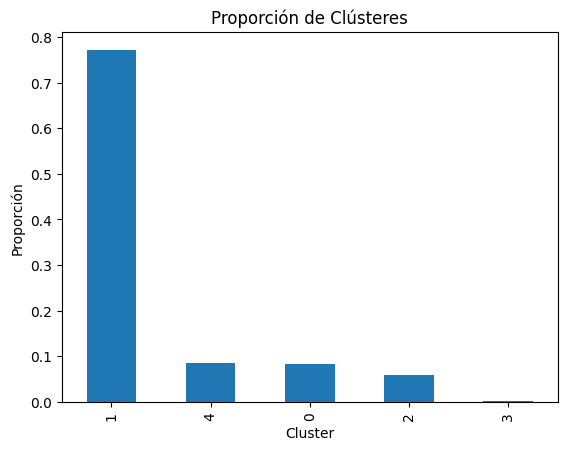

cluster_silhouette
1    0.771853
4    0.084547
0    0.082373
2    0.058687
3    0.002540
Name: proportion, dtype: float64

In [ ]:
# Mostrar tamaños por clúster
df_sample_DEC['cluster_silhouette'].value_counts(normalize=True).plot(kind='bar', title='Proporción de Clústeres')
plt.ylabel("Proporción")
plt.xlabel("Cluster")
plt.show()
df_sample_DEC['cluster_silhouette'].value_counts(normalize=True)

In [ ]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_sample)

df_sample_DEC["pca1"] = pca_result[:, 0]
df_sample_DEC["pca2"] = pca_result[:, 1]


#### Visualización Clusters  Deep Embedding Clustering (DEC)

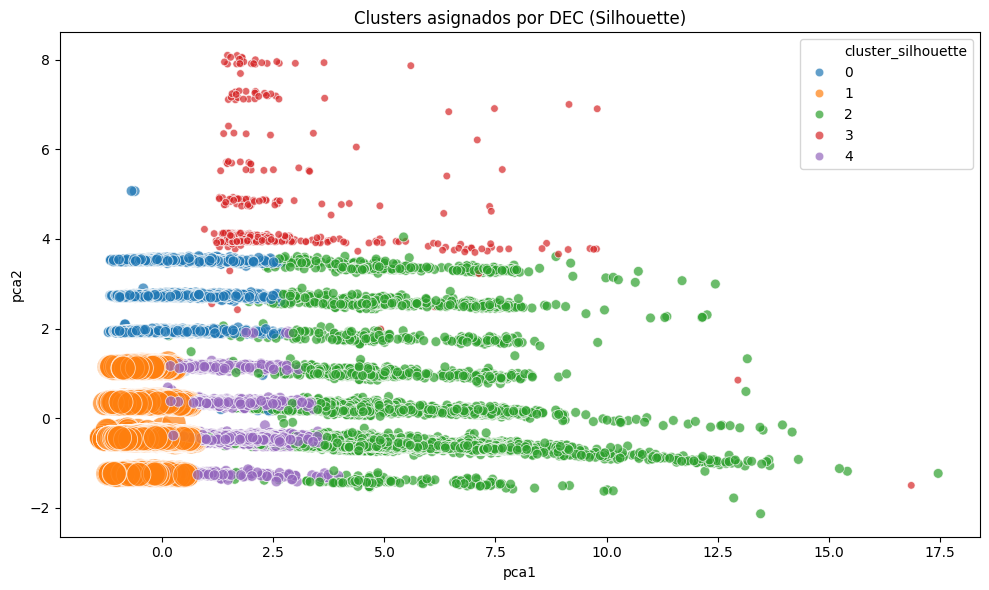

In [ ]:
# Contar elementos por clúster
cluster_counts = df_sample_DEC['cluster_silhouette'].value_counts().to_dict()

# Mapear esos tamaños como escala
df_sample_DEC['cluster_size'] = df_sample_DEC['cluster_silhouette'].map(lambda c: cluster_counts[c])
df_sample_DEC['marker_size'] = df_sample_DEC['cluster_size'] / df_sample_DEC['cluster_size'].max() * 100  # escala

# Eliminar la leyenda de tamaños (marker_size)
# Obtiene los handles y labels actuales
handles, labels = scatter.get_legend_handles_labels()

# Filtra para mantener solo los elementos que son de clúster
new_handles = []
new_labels = []
for h, l in zip(handles, labels):
    if 'marker_size' in l:
        break
    new_handles.append(h)
    new_labels.append(l)


# Visualización
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='pca1',
    y='pca2',
    hue='cluster_silhouette',
    size='marker_size',
    sizes=(30, 300),  # control del rango de tamaño visible
    data=df_sample_DEC,
    alpha=0.7,
    edgecolor='white',
    palette='tab10',
    legend='brief'
)
plt.title("Clusters asignados por DEC (Silhouette)")
plt.legend(new_handles, new_labels, loc='best')
plt.tight_layout()
plt.show()


### Davies - Bouldin

In [ ]:
# Buscar la mejor combinación para la métrica davies_bouldin
mejor_fila_davies_bouldin = resultados_grid_DEC.loc[resultados_grid_DEC['davies_bouldin'].idxmin()]

print("Mejor configuración basada en davies_bouldin:")
print(mejor_fila_davies_bouldin)

# Obtener los hiperparámetros del mejor modelo
best_params_davies_bouldin = {
    "n_clusters": int(mejor_fila_davies_bouldin["n_clusters"]),
    "embedding_dim": int(mejor_fila_davies_bouldin["embedding_dim"]),
    "pretrain_epochs": int(mejor_fila_davies_bouldin["pretrain_epochs"]),
}

Mejor configuración basada en davies_bouldin:
n_clusters                5.000000
embedding_dim            20.000000
pretrain_epochs          30.000000
silhouette                0.487276
davies_bouldin            0.730394
calinski_harabasz    110319.460938
tiempo_s                759.070000
Name: 2, dtype: float64


In [ ]:
# Clustering con KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_embedded)


4688/4688 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step


In [ ]:
df_sample_DEC["cluster_davies_bouldin"] = labels
df_sample_DEC.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,cluster_silhouette,pca1,pca2,cluster_size,marker_size,cluster_davies_bouldin
0,0.397969,-0.463200,-0.221665,-0.223972,-0.907863,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,4,-0.478403,-0.478001,12682,10.953722,3
1,-0.405570,-0.463200,-0.221665,0.026813,0.005213,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1,-0.334576,-0.440547,115778,100.000000,2
2,-0.599528,0.353273,-0.221665,-0.199454,-0.828808,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1,-1.029225,0.351894,115778,100.000000,3
3,-0.546882,-0.463200,-0.221665,-0.153921,-0.610619,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1,-0.810399,-0.467652,115778,100.000000,2
4,-0.521945,3.619164,-0.221665,-0.161393,-0.515754,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0,-0.689826,3.499005,12356,10.672148,0


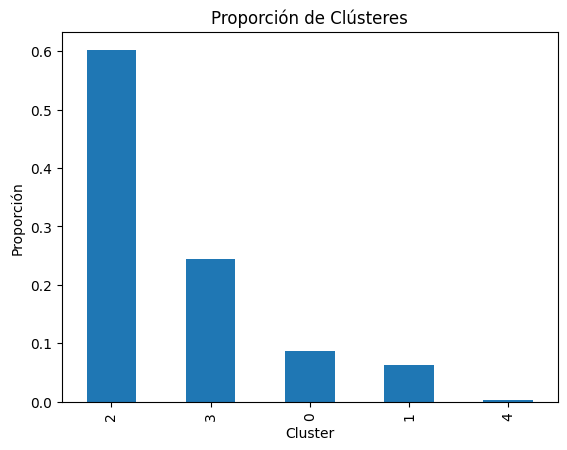

cluster_davies_bouldin
2    0.602233
3    0.244560
0    0.087460
1    0.063200
4    0.002547
Name: proportion, dtype: float64

In [ ]:
# Mostrar tamaños por clúster
df_sample_DEC['cluster_davies_bouldin'].value_counts(normalize=True).plot(kind='bar', title='Proporción de Clústeres')
plt.ylabel("Proporción")
plt.xlabel("Cluster")
plt.show()
df_sample_DEC['cluster_davies_bouldin'].value_counts(normalize=True)

In [ ]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_sample)

df_sample_DEC["pca1_db"] = pca_result[:, 0]
df_sample_DEC["pca2_db"] = pca_result[:, 1]


#### Visualización Clusters  Deep Embedding Clustering (DEC)

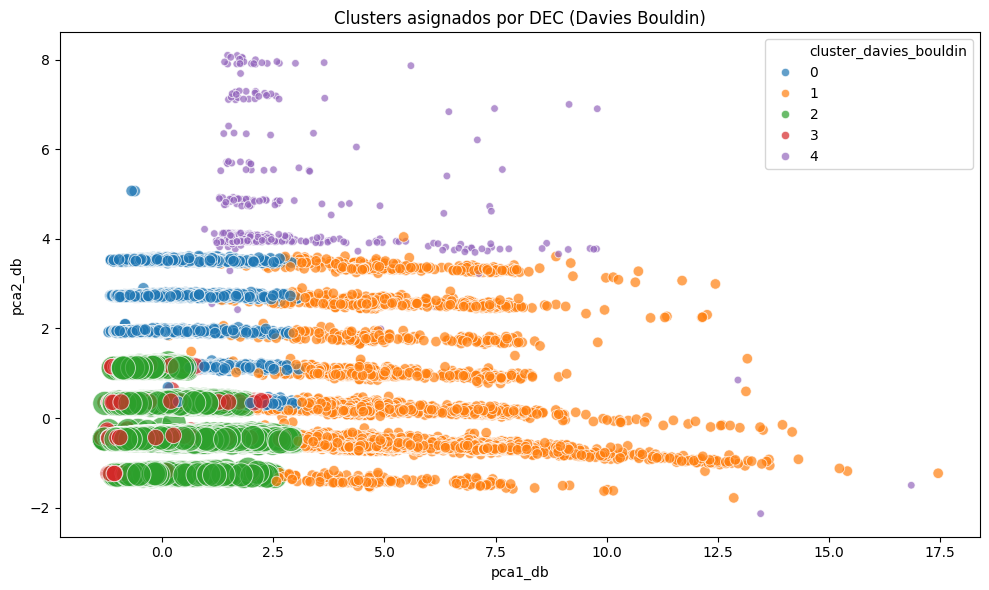

In [ ]:
# Contar elementos por clúster
cluster_counts = df_sample_DEC['cluster_davies_bouldin'].value_counts().to_dict()

# Mapear esos tamaños como escala proporcional
df_sample_DEC['cluster_size_db'] = df_sample_DEC['cluster_davies_bouldin'].map(lambda c: cluster_counts[c])
df_sample_DEC['marker_size_db'] = df_sample_DEC['cluster_size_db'] / df_sample_DEC['cluster_size_db'].max() * 100  # escala relativa

# Visualización
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    x='pca1_db',
    y='pca2_db',
    hue='cluster_davies_bouldin',
    size='marker_size_db',
    sizes=(30, 300),
    data=df_sample_DEC,
    alpha=0.7,
    edgecolor='white',
    palette='tab10',
    legend='brief'
)

# Eliminar la leyenda de tamaños (marker_size)
handles, labels = scatter.get_legend_handles_labels()
new_handles = []
new_labels = []
for h, l in zip(handles, labels):
    if 'marker_size_db' in l:
        break
    new_handles.append(h)
    new_labels.append(l)

# Aplicar solo la leyenda de clusters
plt.legend(new_handles, new_labels, loc='best')

plt.title("Clusters asignados por DEC (Davies Bouldin)")
plt.tight_layout()
plt.show()



### Calinski - Harabasz

In [ ]:
# Buscar la mejor combinación por cada métrica
mejor_fila_calinski_harabasz = resultados_grid_DEC.loc[resultados_grid_DEC['calinski_harabasz'].idxmax()]

print("Mejor configuración basada en calinski_harabasz:")
print(mejor_fila_calinski_harabasz)

# Obtener los hiperparámetros del mejor modelo
best_params_calinski_harabasz = {
    "n_clusters": int(mejor_fila_calinski_harabasz["n_clusters"]),
    "embedding_dim": int(mejor_fila_calinski_harabasz["embedding_dim"]),
    "pretrain_epochs": int(mejor_fila_calinski_harabasz["pretrain_epochs"]),
}

Mejor configuración basada en calinski_harabasz:
n_clusters                6.000000
embedding_dim            10.000000
pretrain_epochs          50.000000
silhouette                0.502141
davies_bouldin            0.778423
calinski_harabasz    156733.734375
tiempo_s                804.020000
Name: 5, dtype: float64


In [ ]:
# Clustering con KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_embedded)


4688/4688 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step


In [ ]:
df_sample_DEC["cluster_calinski_harabasz"] = labels
df_sample_DEC.head()

,0,1,2,3,4,5,6,7,8,9,...,pca1,pca2,cluster_size,marker_size,cluster_davies_bouldin,pca1_db,pca2_db,cluster_size_db,marker_size_db,cluster_calinski_harabasz
0,0.397969,-0.463200,-0.221665,-0.223972,-0.907863,0.0,0.0,1.0,0.0,1.0,...,-0.478403,-0.478001,12682,10.953722,3,-0.478403,-0.478001,36684,40.608845,2
1,-0.405570,-0.463200,-0.221665,0.026813,0.005213,1.0,0.0,0.0,0.0,1.0,...,-0.334576,-0.440547,115778,100.000000,2,-0.334576,-0.440547,90335,100.000000,3
2,-0.599528,0.353273,-0.221665,-0.199454,-0.828808,0.0,1.0,0.0,0.0,1.0,...,-1.029225,0.351894,115778,100.000000,3,-1.029225,0.351894,36684,40.608845,2
3,-0.546882,-0.463200,-0.221665,-0.153921,-0.610619,1.0,0.0,0.0,0.0,1.0,...,-0.810399,-0.467652,115778,100.000000,2,-0.810399,-0.467652,90335,100.000000,3
4,-0.521945,3.619164,-0.221665,-0.161393,-0.515754,1.0,0.0,0.0,0.0,1.0,...,-0.689826,3.499005,12356,10.672148,0,-0.689826,3.499005,13119,14.522610,0


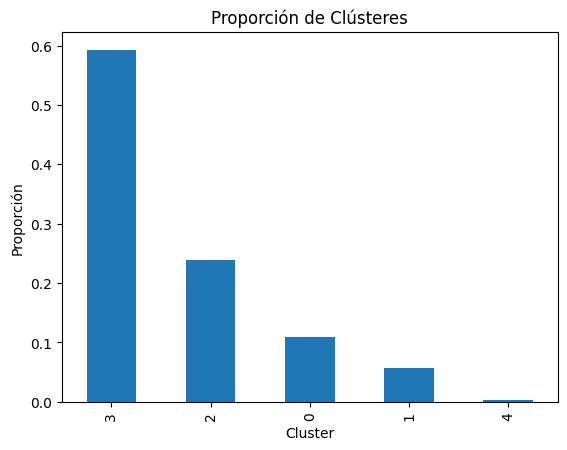

cluster_calinski_harabasz
3    0.592807
2    0.239507
0    0.108727
1    0.056413
4    0.002547
Name: proportion, dtype: float64

In [ ]:
# Mostrar tamaños por clúster
df_sample_DEC['cluster_calinski_harabasz'].value_counts(normalize=True).plot(kind='bar', title='Proporción de Clústeres')
plt.ylabel("Proporción")
plt.xlabel("Cluster")
plt.show()
df_sample_DEC['cluster_calinski_harabasz'].value_counts(normalize=True)

In [ ]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_sample)

df_sample_DEC["pca1_ch"] = pca_result[:, 0]
df_sample_DEC["pca2_ch"] = pca_result[:, 1]


#### Visualización Clusters  Deep Embedding Clustering (DEC)

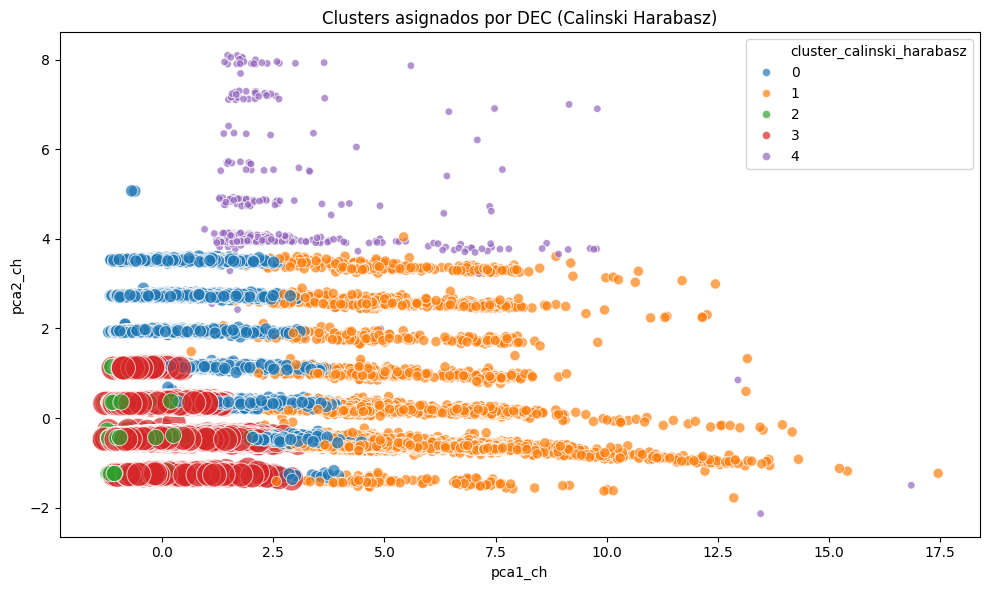

In [ ]:
# Contar elementos por clúster
cluster_counts = df_sample_DEC['cluster_calinski_harabasz'].value_counts().to_dict()

# Mapear esos tamaños como escala proporcional
df_sample_DEC['cluster_size_ch'] = df_sample_DEC['cluster_calinski_harabasz'].map(lambda c: cluster_counts[c])
df_sample_DEC['marker_size_ch'] = df_sample_DEC['cluster_size_ch'] / df_sample_DEC['cluster_size_ch'].max() * 100  # escala relativa

# Visualización
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    x='pca1_ch',
    y='pca2_ch',
    hue='cluster_calinski_harabasz',
    size='marker_size_ch',
    sizes=(30, 300),
    data=df_sample_DEC,
    alpha=0.7,
    edgecolor='white',
    palette='tab10',
    legend='brief'
)

# Eliminar la leyenda de tamaños (marker_size)
handles, labels = scatter.get_legend_handles_labels()
new_handles = []
new_labels = []
for h, l in zip(handles, labels):
    if 'marker_size_ch' in l:
        break
    new_handles.append(h)
    new_labels.append(l)

# Aplicar solo la leyenda de clusters
plt.legend(new_handles, new_labels, loc='best')

plt.title("Clusters asignados por DEC (Calinski Harabasz)")
plt.tight_layout()
plt.show()



## Autoencoder

Silhpuete

In [31]:
# --------------------------
# 1. Custom Transformer (Autoencoder)
# --------------------------
class AutoencoderEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, encoding_dim=3, hidden_units=128, epochs=10, batch_size=32):
        self.encoding_dim = encoding_dim
        self.hidden_units = hidden_units
        self.epochs = epochs
        self.batch_size = batch_size
        self.encoder = None
        self.autoencoder = None

    def build_model(self, input_dim):
        model = keras.Sequential([
            keras.layers.Dense(self.hidden_units, activation='relu', input_shape=(input_dim,)),
            keras.layers.Dense(self.encoding_dim, activation='relu', name='encoder'),
            keras.layers.Dense(self.hidden_units, activation='relu'),
            keras.layers.Dense(input_dim)
        ])
        model.compile(optimizer='adam', loss='mse')
        return model

    def fit(self, X, y=None):
        input_dim = X.shape[1]
        self.autoencoder = self.build_model(input_dim)
        self.autoencoder.fit(X, X, epochs=self.epochs, batch_size=self.batch_size, verbose=0)
        self.encoder = keras.Model(inputs=self.autoencoder.input,
                                   outputs=self.autoencoder.get_layer('encoder').output)
        return self

    def transform(self, X):
        return self.encoder.predict(X, verbose=0)


# --------------------------
# 3. Pipeline: Autoencoder + KMeans
# --------------------------
pipeline = Pipeline([
    ('autoencoder', AutoencoderEncoder()),
    ('kmeans', KMeans(random_state=42, n_init='auto'))
])

# --------------------------
# 4. GridSearchCV
# --------------------------
param_grid = {
    'autoencoder__encoding_dim': [2, 3, 5],
    'autoencoder__hidden_units': [64, 128],
    'kmeans__n_clusters': [2, 3, 4, 5]
}

def silhouette_scorer(estimator, X):
    latent_space = estimator.named_steps['autoencoder'].transform(X)
    labels = estimator.named_steps['kmeans'].fit_predict(latent_space)
    if len(np.unique(labels)) < 2:
        return -1
    return silhouette_score(latent_space, labels)

grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring=silhouette_scorer)

print("🔍 Entrenando Autoencoder + KMeans con búsqueda de hiperparámetros...")
grid_search.fit(X_sample)

# --------------------------
# 5. Resultados
# --------------------------
print("\n✅ Mejores parámetros encontrados:")
print(grid_search.best_params_)

# Obtener etiquetas finales
best_model = grid_search.best_estimator_
X_latent = best_model.named_steps['autoencoder'].transform(X_sample)
final_labels = best_model.named_steps['kmeans'].predict(X_latent)


🔍 Entrenando Autoencoder + KMeans con búsqueda de hiperparámetros...

✅ Mejores parámetros encontrados:
{'autoencoder__encoding_dim': 5, 'autoencoder__hidden_units': 64, 'kmeans__n_clusters': 2}


#### Visualización Clusters Autoencoder

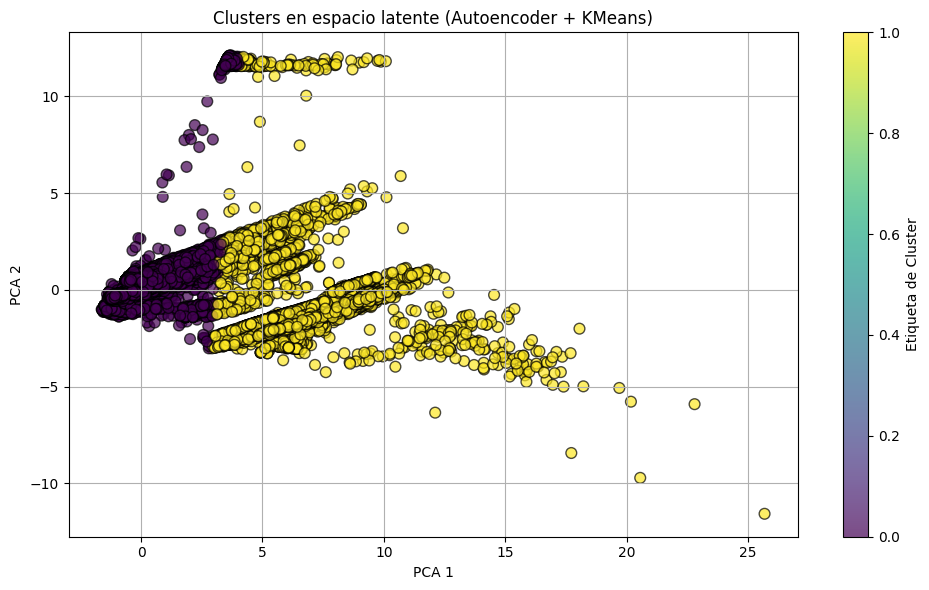

In [32]:
# Reducimos a 2D el espacio latente para visualizar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_latent)

# Visualizamos los clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=final_labels, cmap='viridis', s=60, alpha=0.7, edgecolors='k')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Clusters en espacio latente (Autoencoder + KMeans)')
plt.colorbar(scatter, label='Etiqueta de Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


Davies-Bouldin

In [ ]:

# --------------------------
# Reemplazar la función de evaluación
# --------------------------
def davies_bouldin_scorer(estimator, X):
    latent_space = estimator.named_steps['autoencoder'].transform(X)
    labels = estimator.named_steps['kmeans'].fit_predict(latent_space)
    if len(np.unique(labels)) < 2:
        return float('inf')  # Poner el peor valor posible si solo hay un cluster
    return -davies_bouldin_score(latent_space, labels)  # Negativo porque GridSearchCV maximiza

# --------------------------
# GridSearchCV con nueva métrica
# --------------------------
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring=davies_bouldin_scorer)

print("🔍 Entrenando Autoencoder + KMeans usando Davies-Bouldin Index como métrica...")
grid_search.fit(X_sample)

# --------------------------
# Resultados
# --------------------------
print("\n✅ Mejores parámetros encontrados:")
print(grid_search.best_params_)

# Obtener etiquetas finales
best_model = grid_search.best_estimator_
X_latent = best_model.named_steps['autoencoder'].transform(X_sample)
final_labels = best_model.named_steps['kmeans'].predict(X_latent)

# Imprimir número de clusters encontrados
n_clusters = len(np.unique(final_labels))
print(f"\n🔢 Número de clusters encontrados: {n_clusters}")

# (Opcional) Imprimir el mejor Davies-Bouldin Score
best_score = -grid_search.best_score_  # Volver al valor positivo original
print(f"📉 Mejor Davies-Bouldin Score: {best_score:.4f}")


🔍 Entrenando Autoencoder + KMeans usando Davies-Bouldin Index como métrica...

✅ Mejores parámetros encontrados:
{'autoencoder__encoding_dim': 2, 'autoencoder__hidden_units': 128, 'kmeans__n_clusters': 3}

🔢 Número de clusters encontrados: 3
📉 Mejor Davies-Bouldin Score: 0.3873


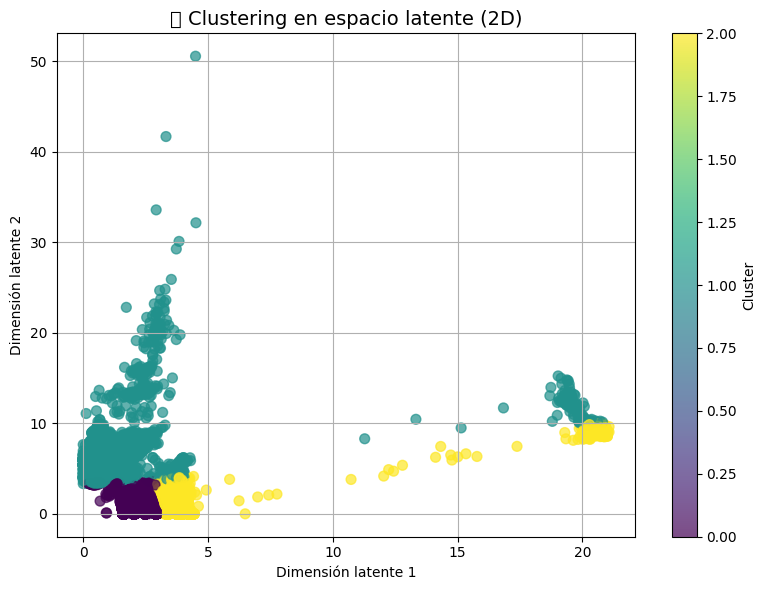

In [ ]:


plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_latent[:, 0], X_latent[:, 1], c=final_labels, cmap='viridis', s=50, alpha=0.7)
plt.title("🔍 Clustering en espacio latente (2D)", fontsize=14)
plt.xlabel("Dimensión latente 1")
plt.ylabel("Dimensión latente 2")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()


Calinski - Harabasz

In [25]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import calinski_harabasz_score
import numpy as np
from tensorflow import keras

# --------------------------
# 1. Custom Transformer (Autoencoder)
# --------------------------
class AutoencoderEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, encoding_dim=3, hidden_units=128, epochs=10, batch_size=32):
        self.encoding_dim = encoding_dim
        self.hidden_units = hidden_units
        self.epochs = epochs
        self.batch_size = batch_size
        self.encoder = None
        self.autoencoder = None

    def build_model(self, input_dim):
        model = keras.Sequential([
            keras.layers.Dense(self.hidden_units, activation='relu', input_shape=(input_dim,)),
            keras.layers.Dense(self.encoding_dim, activation='relu', name='encoder'),
            keras.layers.Dense(self.hidden_units, activation='relu'),
            keras.layers.Dense(input_dim)
        ])
        model.compile(optimizer='adam', loss='mse')
        return model

    def fit(self, X, y=None):
        input_dim = X.shape[1]
        self.autoencoder = self.build_model(input_dim)
        self.autoencoder.fit(X, X, epochs=self.epochs, batch_size=self.batch_size, verbose=0)
        self.encoder = keras.Model(inputs=self.autoencoder.input,
                                   outputs=self.autoencoder.get_layer('encoder').output)
        return self

    def transform(self, X):
        return self.encoder.predict(X, verbose=0)

# --------------------------
# 2. Pipeline + Parámetros
# --------------------------
pipeline = Pipeline([
    ('autoencoder', AutoencoderEncoder()),
    ('kmeans', KMeans(random_state=42, n_init='auto'))
])

param_grid = {
    'autoencoder__encoding_dim': [2, 3, 5],
    'autoencoder__hidden_units': [64, 128],
    'kmeans__n_clusters': [2, 3, 4, 5]
}

# --------------------------
# 3. Scorer Calinski-Harabasz
# --------------------------
def calinski_harabasz_scorer(estimator, X):
    latent = estimator.named_steps['autoencoder'].transform(X)
    labels = estimator.named_steps['kmeans'].fit_predict(latent)
    if len(np.unique(labels)) < 2:
        return 0
    return calinski_harabasz_score(latent, labels)

# --------------------------
# 4. GridSearchCV y entrenamiento
# --------------------------
print("🔍 Entrenando Autoencoder + KMeans usando Calinski-Harabasz Index como métrica...")

grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring=calinski_harabasz_scorer)
grid_search.fit(X_sample)

# --------------------------
# 5. Resultados
# --------------------------
print("\n Mejores parámetros encontrados:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_
X_latent = best_model.named_steps['autoencoder'].transform(X_sample)
final_labels = best_model.named_steps['kmeans'].predict(X_latent)

n_clusters = len(np.unique(final_labels))
print(f"\n Número de clusters encontrados: {n_clusters}")

best_score = grid_search.best_score_
print(f" Mejor Calinski-Harabasz Score: {best_score:.4f}")



🔍 Entrenando Autoencoder + KMeans usando Calinski-Harabasz Index como métrica...

 Mejores parámetros encontrados:
{'autoencoder__encoding_dim': 2, 'autoencoder__hidden_units': 128, 'kmeans__n_clusters': 5}

 Número de clusters encontrados: 5
 Mejor Calinski-Harabasz Score: 105067.4509


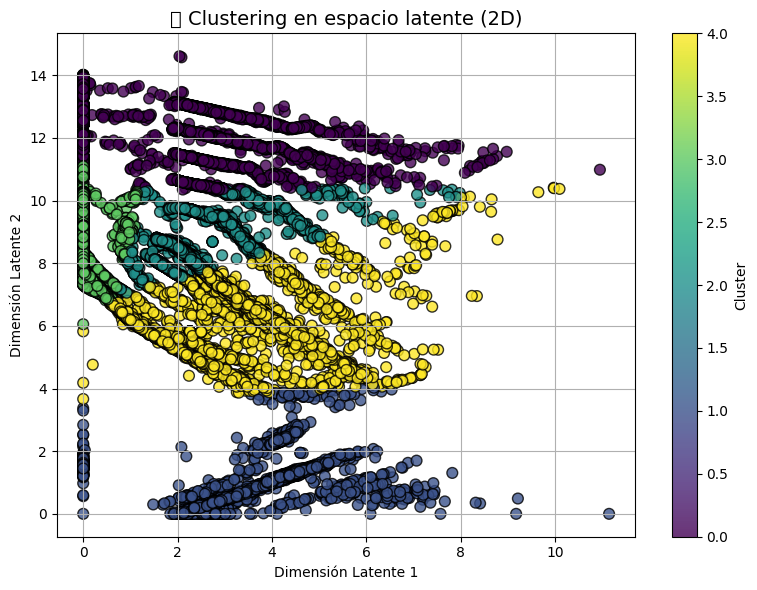

In [26]:

# --------------------------
# Visualización de Clusters en espacio latente (2D)
# --------------------------
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_latent[:, 0], X_latent[:, 1], c=final_labels, cmap='viridis', s=60, alpha=0.8, edgecolors='k')
plt.title("🔍 Clustering en espacio latente (2D)", fontsize=14)
plt.xlabel("Dimensión Latente 1")
plt.ylabel("Dimensión Latente 2")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

